## PROYECTO 2:ESTUDIO DE SEÑALES EEG DEL FUNCIONAMIENTO Y EL CONTROL DEL MOVIMIENTO (imaginería motora) CON ENFOQUE EN EVALUACIÓN DE SISTEMAS DE INTERFAZ CEREBRO-COMPUTADORA (BCI)
### Dataset: EEG Motor Movement/Imagery – PhysioNet / OpenNeuro ds004362
#### **Autoras:** [Luisa Fernanda Llamas Baldovino, Camila Andrea Montiel Zapata]
#### **Laboratorio de Bioseñales – UdeA 2026-1**

> **Guía de lectura:** Este notebook implementa cada etapa del flujo de procesamiento de señales para BCI de forma independiente y paso a paso.


In [2]:
# ─── Importación de librerías ───────────────────────────────────────
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import signal as sp_signal
from scipy.signal import firwin, filtfilt, hilbert
from scipy.stats import shapiro, wilcoxon, ttest_rel

import mne
mne.set_log_level('WARNING')



In [3]:
# Machine Learning
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

try:
    import antropy as ant
    ANTROPY_OK = True
except ImportError:
    ANTROPY_OK = False
    print('antropy no instalado, se usará implementación propia para SampEn')

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print('xgboost no instalado: pip install xgboost')


antropy no instalado, se usará implementación propia para SampEn


In [4]:

# ─── Parámetros globales ─────────────────────────────────────────────
SFREQ           = 160          # Hz
CANALES_INTERES = ['C3', 'Cz', 'C4']
L_FREQ, H_FREQ  = 8.0, 30.0   # Banda motora Mu + Beta
MU_BAND         = (8, 13)      # Hz
BETA_BAND       = (13, 30)     # Hz
TMIN, TMAX      = 0.0, 4.0     # Ventana de época (segundos)
M_WELCH         = 128          # Muestras por segmento Welch
S_WELCH         = M_WELCH // 2

# ─── Etiquetas de clases ─────────────────────────────────────────────
NOMBRES_CLASE = {0: 'Reposo (T0)', 1: 'Img Izq (T1)', 2: 'Img Der (T2)'}
COLORES_CLASE = {0: '#7F8C8D', 1: '#2980B9', 2: '#E74C3C'}


## **1. Configuración de rutas y búsqueda de archivos**
Solo usamos los archivos de **imaginación motora** (R04, R08, R12)
donde T1 = puño izquierdo y T2 = puño derecho.

In [5]:

RUTA_BASE = r'C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files'

N_SUJETOS        = 109
RUNS_IMAGINACION = ['R04', 'R08', 'R12']
todos_sujetos    = [f'S{i:03d}' for i in range(1, N_SUJETOS + 1)]

archivos_img = []
for sujeto in todos_sujetos:
    for run in RUNS_IMAGINACION:
        ruta = os.path.join(RUTA_BASE, sujeto, f'{sujeto}{run}.edf')
        if os.path.exists(ruta):
            archivos_img.append(ruta)

archivos_img.sort()
print(f'Archivos encontrados: {len(archivos_img)}')
print(f'Esperados: {N_SUJETOS * len(RUNS_IMAGINACION)}')
print('\nPrimeros 5:')
for a in archivos_img[:5]:
    print(' ', os.path.basename(a))


Archivos encontrados: 327
Esperados: 327

Primeros 5:
  S001R04.edf
  S001R08.edf
  S001R12.edf
  S002R04.edf
  S002R08.edf


## **2.Preprocesamiento de las señales.**


### **2.1Funciones de preprocesamiento (reutilizadas del Proyecto 1)**

Retomamos el pipeline del Proyecto 1:
- **CAR (Common Average Reference):** le resta a cada electrodo el promedio de todos.
  Esto cancela el ruido eléctrico que aparece igual en todos los canales
  (por ejemplo interferencia de red eléctrica a 60 Hz).
- **Filtro FIR pasabanda 8–30 Hz:** nos quedamos solo con las bandas Mu (8–13 Hz)
  y Beta (13–30 Hz) que son las que cambian durante la imaginación motora.
  Usamos `filtfilt` para que el filtro no cause desfase en la señal.
- **Segmentación en épocas:** cada evento (T0, T1, T2) se convierte en una
  ventana de 4 segundos que es nuestra unidad de análisis.

In [6]:
def aplicar_CAR(raw_obj):
    """
    Aplica Referencia Común a la Media (CAR).
    Elimina ruido eléctrico de modo común presente en todos los electrodos.
    x_CAR[n] = x_i[n] - (1/N) * sum_j(x_j[n])
    """
    raw_car = raw_obj.copy()
    datos   = raw_car.get_data()
    raw_car[:] = datos - datos.mean(axis=0)
    return raw_car


def aplicar_filtro_FIR(raw_car, l_freq=L_FREQ, h_freq=H_FREQ):
    """
    Filtro FIR pasabanda (8-30 Hz) de fase cero (filtfilt).
    Aísla bandas Mu y Beta eliminando artefactos de baja frecuencia y EMG.
    """
    fs     = raw_car.info['sfreq']
    delta_f = 2.0
    N_fir   = int(np.ceil(3.3 * fs / delta_f))
    if N_fir % 2 == 0:
        N_fir += 1
    b = firwin(N_fir, [l_freq, h_freq], fs=fs, window='hamming', pass_zero=False)

    raw_filt = raw_car.copy()
    datos    = raw_car.get_data()
    raw_filt[:] = filtfilt(b, [1.0], datos, axis=1)
    return raw_filt


def segmentar_epocas(raw_filt, tmin=TMIN, tmax=TMAX):
    """
    Segmenta la señal filtrada en épocas según marcadores.
    T0 = reposo, T1 = mano izquierda, T2 = mano derecha.
    Retorna dict {evento: Epochs MNE}
    """
    events, event_id = mne.events_from_annotations(raw_filt, verbose='WARNING')
    epochs_all = mne.Epochs(
        raw_filt, events, event_id=event_id,
        tmin=tmin, tmax=tmax,
        baseline=None, preload=True, verbose='WARNING'
    )
    epocas = {}
    for nombre in event_id.keys():
        try:
            epocas[str(nombre)] = epochs_all[str(nombre)]
        except:
            pass
    return epocas, event_id, epochs_all


def preprocesar_archivo(ruta_edf):
    """
    Flujo completo de preprocesamiento: carga → CAR → FIR → épocas.
    Retorna (epocas_dict, event_id) o (None, None) si falla.
    """
    try:
        raw = mne.io.read_raw_edf(ruta_edf, preload=True, verbose='WARNING')
        raw.rename_channels(lambda x: x.strip('.'))
        # Verificar que existan los canales de interés
        disponibles = set(raw.ch_names)
        if not all(c in disponibles for c in CANALES_INTERES):
            return None, None
        raw_car  = aplicar_CAR(raw)
        raw_filt = aplicar_filtro_FIR(raw_car)
        epocas, event_id, _ = segmentar_epocas(raw_filt)
        return epocas, event_id
    except Exception as e:
        return None, None

print("✔ Funciones de preprocesamiento definidas")

✔ Funciones de preprocesamiento definidas


## **3. Visualización de línea base: PSD y espectrograma**

Antes de extraer características, miramos visualmente la señal de un
sujeto de prueba para confirmar que el preprocesamiento funciona bien y para
justificar nuestras decisiones de diseño.

**¿Qué esperamos ver?**
- En la PSD: una caída de potencia en la banda Mu (8–13 Hz) en C3 o C4
  durante la imaginación motora respecto al reposo.
- En el espectrograma: esa misma caída pero en el tiempo, lo que confirma
  que los 4 segundos de ventana capturan bien el evento.

Visualizando: S001R04.edf


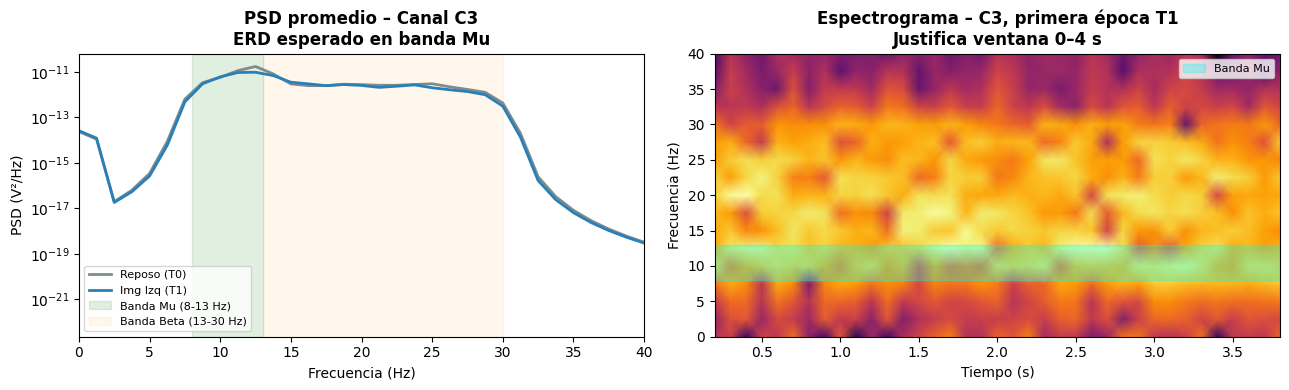

Figura guardada: figuras_P2/01_psd_espectrograma.png


In [7]:
# ── Cargar un solo archivo para visualización ────────────────────
if len(archivos_img) == 0:
    print('No se encontraron archivos. Revisar RUTA_BASE.')
else:
    ruta_prueba = archivos_img[0]   # S001R04.edf
    print(f'Visualizando: {os.path.basename(ruta_prueba)}')

    epocas_prueba, event_id_prueba = preprocesar_archivo(ruta_prueba)

    if epocas_prueba is None:
        print('No se pudo cargar el archivo.')
    else:
        # Obtener datos de C3 para T0 y T1
        idx_C3 = epocas_prueba.get(list(epocas_prueba.keys())[0]).ch_names.index('C3')

        datos_T0 = None
        datos_T1 = None

        for key in epocas_prueba:
            ep = epocas_prueba[key]
            data_c3 = ep.get_data()[:, idx_C3, :]   # (n_epocas, n_muestras)
            if 'T0' in key or key == '1':
                datos_T0 = data_c3
            elif 'T1' in key or key == '2':
                datos_T1 = data_c3

        if datos_T0 is not None and datos_T1 is not None:
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))

            # ── Panel izquierdo: PSD promedio ─────────────────────
            for datos, label, color in [
                    (datos_T0, 'Reposo (T0)',    COLORES_CLASE[0]),
                    (datos_T1, 'Img Izq (T1)',   COLORES_CLASE[1])]:

                # Calcular PSD para cada época y promediar
                psds = []
                for ep in datos:
                    f, Pxx = sp_signal.welch(ep, fs=SFREQ, nperseg=M_WELCH, noverlap=S_WELCH)
                    psds.append(Pxx)
                psd_mean = np.mean(psds, axis=0)

                axes[0].semilogy(f, psd_mean, label=label, color=color, lw=2)

            axes[0].axvspan(8, 13, alpha=0.12, color='green', label='Banda Mu (8-13 Hz)')
            axes[0].axvspan(13, 30, alpha=0.08, color='orange', label='Banda Beta (13-30 Hz)')
            axes[0].set_xlim(0, 40)
            axes[0].set_xlabel('Frecuencia (Hz)')
            axes[0].set_ylabel('PSD (V²/Hz)')
            axes[0].set_title('PSD promedio – Canal C3\nERD esperado en banda Mu', fontweight='bold')
            axes[0].legend(fontsize=8)

            # ── Panel derecho: espectrograma de la primera época T1 ──
            f_sg, t_sg, Sxx = sp_signal.spectrogram(
                datos_T1[0], fs=SFREQ, nperseg=64, noverlap=48
            )
            mascara = f_sg <= 40
            axes[1].pcolormesh(t_sg, f_sg[mascara], 10*np.log10(Sxx[mascara] + 1e-30),
                               shading='gouraud', cmap='inferno')
            axes[1].axhspan(8, 13, alpha=0.3, color='cyan', label='Banda Mu')
            axes[1].set_xlabel('Tiempo (s)')
            axes[1].set_ylabel('Frecuencia (Hz)')
            axes[1].set_title('Espectrograma – C3, primera época T1\n'
                              'Justifica ventana 0–4 s', fontweight='bold')
            axes[1].legend(fontsize=8)

            plt.tight_layout()
            plt.savefig('figuras_P2/01_psd_espectrograma.png', dpi=150, bbox_inches='tight')
            plt.show()
            print('Figura guardada: figuras_P2/01_psd_espectrograma.png')
        else:
            print('No se encontraron épocas T0/T1. Revisar nombres de anotaciones.')


## **4. Extracción de características**

Ahora definimos las funciones para calcular cada índice.
Las vamos presentando de a una para que quede claro qué hace cada una.


### **4.1 PSD en bandas Mu y Beta (método de Welch)**

La PSD nos dice cuánta energía tiene la señal en cada frecuencia.
Nosotros nos interesa la potencia dentro de las bandas Mu (8–13 Hz)
y Beta (13–30 Hz) porque son las que se modifican durante la imaginación motora.
Usamos el método de Welch porque divide la señal en segmentos, calcula la PSD
de cada uno y promedia, lo que reduce el ruido del estimado.

In [8]:
def calcular_psd_banda(senal_1d, fs=SFREQ, banda=(8, 13)):
    """
    Calcula la potencia promedio en una banda de frecuencia usando Welch.
    Devuelve un número (en V²).
    """
    f, Pxx = sp_signal.welch(senal_1d, fs=fs, nperseg=M_WELCH, noverlap=S_WELCH)
    mascara = (f >= banda[0]) & (f <= banda[1])
    return float(np.mean(Pxx[mascara]))

print('calcular_psd_banda() definida')


calcular_psd_banda() definida


### **4.2 Parámetros de Hjorth (Actividad, Movilidad, Complejidad)**

Estos tres parámetros describen la señal en el dominio del tiempo sin necesitar
transformadas costosas computacionalmente:

- **Actividad:** es simplemente la varianza de la señal. Nos dice cuánta
  energía total tiene la señal en esa ventana.
- **Movilidad:** relaciona la primera derivada de la señal con la señal misma.
  Es una especie de frecuencia media. Si la señal oscila rápido, la movilidad es alta.
- **Complejidad:** compara cómo cambia la frecuencia a lo largo del tiempo.
  Una señal pura (como un seno) tiene complejidad baja; el EEG durante
  imaginación activa tiene complejidad más alta.


In [9]:
def hjorth_params(senal_1d):
    """
    Calcula los 3 parámetros de Hjorth.
    Usamos np.diff para las derivadas (evitamos for).
    """
    d1 = np.diff(senal_1d)     # primera derivada discreta
    d2 = np.diff(d1)           # segunda derivada

    var_x  = np.var(senal_1d, ddof=1)
    var_d1 = np.var(d1, ddof=1)
    var_d2 = np.var(d2, ddof=1)

    actividad   = var_x
    movilidad   = np.sqrt(var_d1 / var_x)  if var_x  > 0 else 0.0
    mob_d1      = np.sqrt(var_d2 / var_d1) if var_d1 > 0 else 0.0
    complejidad = mob_d1 / movilidad        if movilidad > 0 else 0.0

    return actividad, movilidad, complejidad

print('hjorth_params() definida')

hjorth_params() definida


### **4.3 Sample Entropy (entropía muestral)**

La Sample Entropy mide qué tan predecible (o caótica) es la señal.
Un valor alto significa que la señal es irregular (difícil de predecir),
lo que ocurre durante la imaginación motora porque el cortex se activa
y la señal se vuelve más compleja que en reposo (donde domina el ritmo Mu).


In [10]:
def sample_entropy_manual(senal, m=2, r_factor=0.2):
    """
    Implementación básica de Sample Entropy cuando antropy no está disponible.
    m: longitud de los patrones a comparar
    r: tolerancia = r_factor * desviación estándar de la señal
    """
    N = len(senal)
    r = r_factor * np.std(senal, ddof=1)
    if r == 0:
        return 0.0

    def contar_matches(m_dim):
        templates = np.array([senal[i:i + m_dim] for i in range(N - m_dim)])
        count = 0
        for i in range(len(templates)):
            diffs = np.max(np.abs(templates - templates[i]), axis=1)
            diffs[i] = r + 1   # excluir autocomparación
            count += np.sum(diffs < r)
        return count

    A = contar_matches(m + 1)
    B = contar_matches(m)
    if B == 0 or A == 0:
        return 0.0
    return float(-np.log(A / B))


def calcular_sampen(senal_1d):
    """Wrapper: usa antropy si está disponible."""
    if ANTROPY_OK:
        try:
            return float(ant.sample_entropy(senal_1d))
        except Exception:
            pass
    return sample_entropy_manual(senal_1d)

print('calcular_sampen() definida')

calcular_sampen() definida


### **4.4 Phase Locking Value (PLV) entre C3 y C4**

El PLV mide qué tan sincronizadas en fase están las señales de C3 y C4
(hemisferio izquierdo y derecho respectivamente).

- **PLV cercano a 1:** los dos hemisferios oscilan en fase → están sincronizados.
  Esto ocurre en reposo, donde domina el ritmo Mu bilateral.
- **PLV cercano a 0:** los hemisferios se desacoplan → uno se activa independientemente.
  Durante imaginación de mano izquierda, el hemisferio derecho (C4) se activa
  mientras el izquierdo (C3) cambia poco, y viceversa para mano derecha.

Para calcularlo usamos la transformada de Hilbert que extrae la fase instantánea
de cada señal y luego medimos qué tan consistente es la diferencia de fase.


In [11]:
def calcular_plv(senal_c3, senal_c4):
    """
    PLV en la banda Mu entre C3 y C4.
    Fórmula: |mean(exp(j * (fase_C3 - fase_C4)))|
    """
    fase_c3 = np.angle(hilbert(senal_c3))
    fase_c4 = np.angle(hilbert(senal_c4))
    plv = np.abs(np.mean(np.exp(1j * (fase_c3 - fase_c4))))
    return float(plv)

print('calcular_plv() definida')

calcular_plv() definida



## **5. Función principal: extrae todas las características de una época**

Esta función recibe los datos de una época (array de canales × muestras)
y devuelve un diccionario con todos los índices calculados para los
canales de interés. Luego la aplicaremos a todas las épocas del dataset.

Calculamos por cada canal: PSD Mu, PSD Beta, Hjorth×3, SampEn.
Y para el par C3–C4: PLV (solo tiene sentido inter-hemisférico).
Eso nos da **19 características por época**.


In [12]:
def extraer_features_epoca(datos_epoca, ch_names):
    """
    datos_epoca: array de forma (n_canales, n_muestras)
    ch_names   : lista con los nombres de los canales en datos_epoca

    Devuelve un dict con todas las características calculadas.
    """
    feats = {}

    for canal in CANALES_INTERES:
        if canal not in ch_names:
            continue
        idx = ch_names.index(canal)
        s   = datos_epoca[idx]   # señal 1D de ese canal

        # PSD en bandas Mu y Beta
        feats[f'psd_mu_{canal}']   = calcular_psd_banda(s, banda=MU_BAND)
        feats[f'psd_beta_{canal}'] = calcular_psd_banda(s, banda=BETA_BAND)

        # Parámetros de Hjorth
        act, mob, comp = hjorth_params(s)
        feats[f'hjorth_act_{canal}']  = act
        feats[f'hjorth_mob_{canal}']  = mob
        feats[f'hjorth_comp_{canal}'] = comp

        # Sample Entropy
        feats[f'sampen_{canal}'] = calcular_sampen(s)

    # PLV entre C3 y C4 (solo si ambos están disponibles)
    if 'C3' in ch_names and 'C4' in ch_names:
        idx_c3 = ch_names.index('C3')
        idx_c4 = ch_names.index('C4')
        feats['plv_c3_c4_mu'] = calcular_plv(
            datos_epoca[idx_c3], datos_epoca[idx_c4]
        )

    return feats

print('extraer_features_epoca() definida')
print(f'Características por época: PSD(6) + Hjorth(9) + SampEn(3) + PLV(1) = 19')


extraer_features_epoca() definida
Características por época: PSD(6) + Hjorth(9) + SampEn(3) + PLV(1) = 19


## **6. Prueba: extraer características de una sola época**

Antes de procesar los 109 sujetos, verificamos que la función funciona bien
con un ejemplo. Esto nos permite ver cómo queda el DataFrame fila por fila
y detectar errores antes de correr todo el dataset (que puede tomar varios minutos).

In [13]:
# Usar el archivo de prueba cargado antes (S001R04)
if epocas_prueba is not None:
    clave_prueba = list(epocas_prueba.keys())[0]
    ep_obj       = epocas_prueba[clave_prueba]

    # Tomar la primera época: shape (n_canales, n_muestras)
    datos_1_epoca = ep_obj.get_data()[0]
    ch_names_prueba = ep_obj.ch_names

    feats_prueba = extraer_features_epoca(datos_1_epoca, ch_names_prueba)

    print('Características de la primera época:')
    print('-' * 45)
    for k, v in feats_prueba.items():
        print(f'  {k:<30}: {v:.6f}')
else:
    print('No hay archivo de prueba cargado. Ejecutar la sección 4 primero.')


Características de la primera época:
---------------------------------------------
  psd_mu_C3                     : 0.000000
  psd_beta_C3                   : 0.000000
  hjorth_act_C3                 : 0.000000
  hjorth_mob_C3                 : 0.732365
  hjorth_comp_C3                : 1.154262
  sampen_C3                     : 1.049638
  psd_mu_Cz                     : 0.000000
  psd_beta_Cz                   : 0.000000
  hjorth_act_Cz                 : 0.000000
  hjorth_mob_Cz                 : 0.644375
  hjorth_comp_Cz                : 1.257263
  sampen_Cz                     : 1.117801
  psd_mu_C4                     : 0.000000
  psd_beta_C4                   : 0.000000
  hjorth_act_C4                 : 0.000000
  hjorth_mob_C4                 : 0.659124
  hjorth_comp_C4                : 1.203697
  sampen_C4                     : 0.992431
  plv_c3_c4_mu                  : 0.092492


## **7. Pipeline poblacional: procesar todos los sujetos y guardar en DataFrame**

Esta es la parte más lenta del proyecto. Por eso guardamos el resultado
en un archivo CSV para no tener que recalcular todo cada vez que
abrimos el notebook.

Cada fila del DataFrame corresponde a una época de un sujeto, con columnas:
`sujeto | run | tarea | psd_mu_C3 | ... | plv_c3_c4_mu`


In [14]:
def procesar_archivo_a_df(ruta_edf, sujeto_id, run_id):
    """
    Procesa un archivo .edf y devuelve un DataFrame con las características
    de todas sus épocas.
    """
    epocas, event_id = preprocesar_archivo(ruta_edf)
    if epocas is None:
        return pd.DataFrame()   # devolver vacío si falla

    # Mapear nombres de anotaciones a clases numéricas
    # En PhysioNet: T0=reposo, T1=izq, T2=der
    mapa_clases = {}
    for nombre in event_id.keys():
        nombre_str = str(nombre).upper()
        if 'T0' in nombre_str or nombre_str == '1':
            mapa_clases[str(nombre)] = 0
        elif 'T1' in nombre_str or nombre_str == '2':
            mapa_clases[str(nombre)] = 1
        elif 'T2' in nombre_str or nombre_str == '3':
            mapa_clases[str(nombre)] = 2

    filas = []
    for nombre_evento, clase in mapa_clases.items():
        if nombre_evento not in epocas:
            continue
        ep_obj   = epocas[nombre_evento]
        ch_names = ep_obj.ch_names
        datos    = ep_obj.get_data()   # (n_epocas, n_canales, n_muestras)

        for i in range(len(datos)):
            feats = extraer_features_epoca(datos[i], ch_names)
            feats['sujeto'] = sujeto_id
            feats['run']    = run_id
            feats['tarea']  = clase
            filas.append(feats)

    return pd.DataFrame(filas)

print('procesar_archivo_a_df() definida')


procesar_archivo_a_df() definida


In [15]:
# ── Ejecutar sobre todos los archivos ────────────────────────────
# Si ya guardamos el CSV antes, lo cargamos directamente.
RUTA_CSV = 'figuras_P2/features_BCI.csv'

if os.path.exists(RUTA_CSV):
    df_features = pd.read_csv(RUTA_CSV)
    print(f'CSV cargado desde disco: {df_features.shape}')

else:
    print('Procesando todos los archivos... (puede tardar varios minutos)')
    todos_dfs = []

    for i, ruta in enumerate(archivos_img):
        nombre = os.path.basename(ruta)   # ej. S001R04.edf
        sujeto = nombre[:4]               # S001
        run    = nombre[4:7]              # R04

        df_arch = procesar_archivo_a_df(ruta, sujeto, run)
        if not df_arch.empty:
            todos_dfs.append(df_arch)

        if (i + 1) % 50 == 0:
            print(f'  Procesados {i+1}/{len(archivos_img)} archivos')

    df_features = pd.concat(todos_dfs, ignore_index=True)
    df_features.to_csv(RUTA_CSV, index=False)
    print(f'Procesamiento completado. CSV guardado en: {RUTA_CSV}')

print(f'\nDimensiones del DataFrame: {df_features.shape}')
print(f'Épocas por tarea:')
print(df_features['tarea'].value_counts().rename(NOMBRES_CLASE))
df_features.head(3)


Procesando todos los archivos... (puede tardar varios minutos)
  Procesados 50/327 archivos
  Procesados 100/327 archivos
  Procesados 150/327 archivos
  Procesados 200/327 archivos
  Procesados 250/327 archivos
  Procesados 300/327 archivos
Procesamiento completado. CSV guardado en: figuras_P2/features_BCI.csv

Dimensiones del DataFrame: (9816, 22)
Épocas por tarea:
tarea
Reposo (T0)     4918
Img Izq (T1)    2470
Img Der (T2)    2428
Name: count, dtype: int64


,psd_mu_C3,psd_beta_C3,hjorth_act_C3,hjorth_mob_C3,hjorth_comp_C3,sampen_C3,psd_mu_Cz,psd_beta_Cz,hjorth_act_Cz,hjorth_mob_Cz,...,psd_mu_C4,psd_beta_C4,hjorth_act_C4,hjorth_mob_C4,hjorth_comp_C4,sampen_C4,plv_c3_c4_mu,sujeto,run,tarea
0,2.670611e-12,2.398385e-12,5.618003e-11,0.732365,1.154262,1.049638,6.659692e-12,2.345201e-12,7.671033e-11,0.644375,...,5.531906e-12,2.754926e-12,7.260952e-11,0.659124,1.203697,0.992431,0.092492,S001,R04,0
1,4.143366e-12,2.310088e-12,6.589132e-11,0.708745,1.186313,1.154126,5.196227e-12,1.608145e-12,5.558802e-11,0.648040,...,3.538467e-12,1.866851e-12,5.013629e-11,0.687727,1.192612,1.057854,0.174860,S001,R04,0
2,9.854921e-12,1.807666e-12,7.678088e-11,0.593381,1.248905,1.052405,4.948829e-12,1.803470e-12,5.299404e-11,0.665931,...,9.612105e-12,2.506135e-12,8.655053e-11,0.616681,1.242767,0.942068,0.245563,S001,R04,0



## **8. Análisis de resultados: estadística descriptiva**

Usamos boxplots **independientes por característica** porque las unidades
y escalas son muy distintas entre índices (por ejemplo, SampEn está en
escala de nats mientras que la PSD está en V²/Hz). Si graficáramos todo
junto en un solo eje, las características con valores grandes aplastarían
visualmente a las más pequeñas y no podríamos ver nada útil.

Un boxplot nos muestra: mediana (línea central), rango intercuartil (caja),
valores atípicos (puntos) y distribución por condición.


In [16]:
# Columnas de características (todo excepto metadatos)
cols_meta  = ['sujeto', 'run', 'tarea']
cols_feat  = [c for c in df_features.columns if c not in cols_meta]

# Crear una versión del DataFrame con nombres de clase para las gráficas
df_plot = df_features.copy()
df_plot['condicion'] = df_plot['tarea'].map(NOMBRES_CLASE)

print(f'Características disponibles ({len(cols_feat)}):')
for c in cols_feat:
    print(f'  {c}')


Características disponibles (19):
  psd_mu_C3
  psd_beta_C3
  hjorth_act_C3
  hjorth_mob_C3
  hjorth_comp_C3
  sampen_C3
  psd_mu_Cz
  psd_beta_Cz
  hjorth_act_Cz
  hjorth_mob_Cz
  hjorth_comp_Cz
  sampen_Cz
  psd_mu_C4
  psd_beta_C4
  hjorth_act_C4
  hjorth_mob_C4
  hjorth_comp_C4
  sampen_C4
  plv_c3_c4_mu


In [17]:
# ── Función auxiliar para graficar un grupo de features ────────────────────
def boxplot_grupo(feats, titulo_grupo, nombre_archivo, df_plot, orden, paleta):
    """
    Recibe una lista de columnas, verifica cuáles existen y las grafica.
    n_cols fijo en 3 para que los gráficos sean más anchos y legibles.
    """
    feats_ok = [f for f in feats if f in df_plot.columns]
    if not feats_ok:
        print(f'  ⚠ Ninguna feature disponible para: {titulo_grupo}')
        return

    n_cols = 3
    n_rows = int(np.ceil(len(feats_ok) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 5, n_rows * 4.2),
                             squeeze=False)
    axes_flat = axes.flatten()

    for i, feat in enumerate(feats_ok):
        ax = axes_flat[i]
        sns.boxplot(
            data=df_plot, x='condicion', y=feat,
            order=orden, palette=paleta,
            ax=ax, width=0.5, linewidth=1.0,
            flierprops=dict(marker='.', markersize=3, alpha=0.35)
        )
        # Anotar mediana sobre cada caja
        for j, cond in enumerate(orden):
            vals = df_plot[df_plot['condicion'] == cond][feat].dropna()
            if len(vals) > 0:
                med = vals.median()
                ax.text(j, med, f'{med:.3g}',
                        ha='center', va='bottom', fontsize=7.5,
                        color='black', fontweight='bold')
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=8, rotation=12)

    # Apagar ejes sobrantes
    for j in range(len(feats_ok), len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(titulo_grupo, fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    ruta = f'figuras_P2/{nombre_archivo}'
    plt.savefig(ruta, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'→ Figura guardada: {ruta}')

paleta = [COLORES_CLASE[0], COLORES_CLASE[1], COLORES_CLASE[2]]
orden  = [NOMBRES_CLASE[0], NOMBRES_CLASE[1], NOMBRES_CLASE[2]]
print('✔ Función boxplot_grupo() lista')

✔ Función boxplot_grupo() lista


### **8.1 PSD – Banda Mu (8–13 Hz)**

La PSD en banda Mu es el marcador clásico de la ERD sensoriomotora.
Se espera que durante imaginación motora **baje** respecto al reposo
en el canal contralateral al movimiento imaginado (C3 para mano derecha, C4 para mano izquierda).

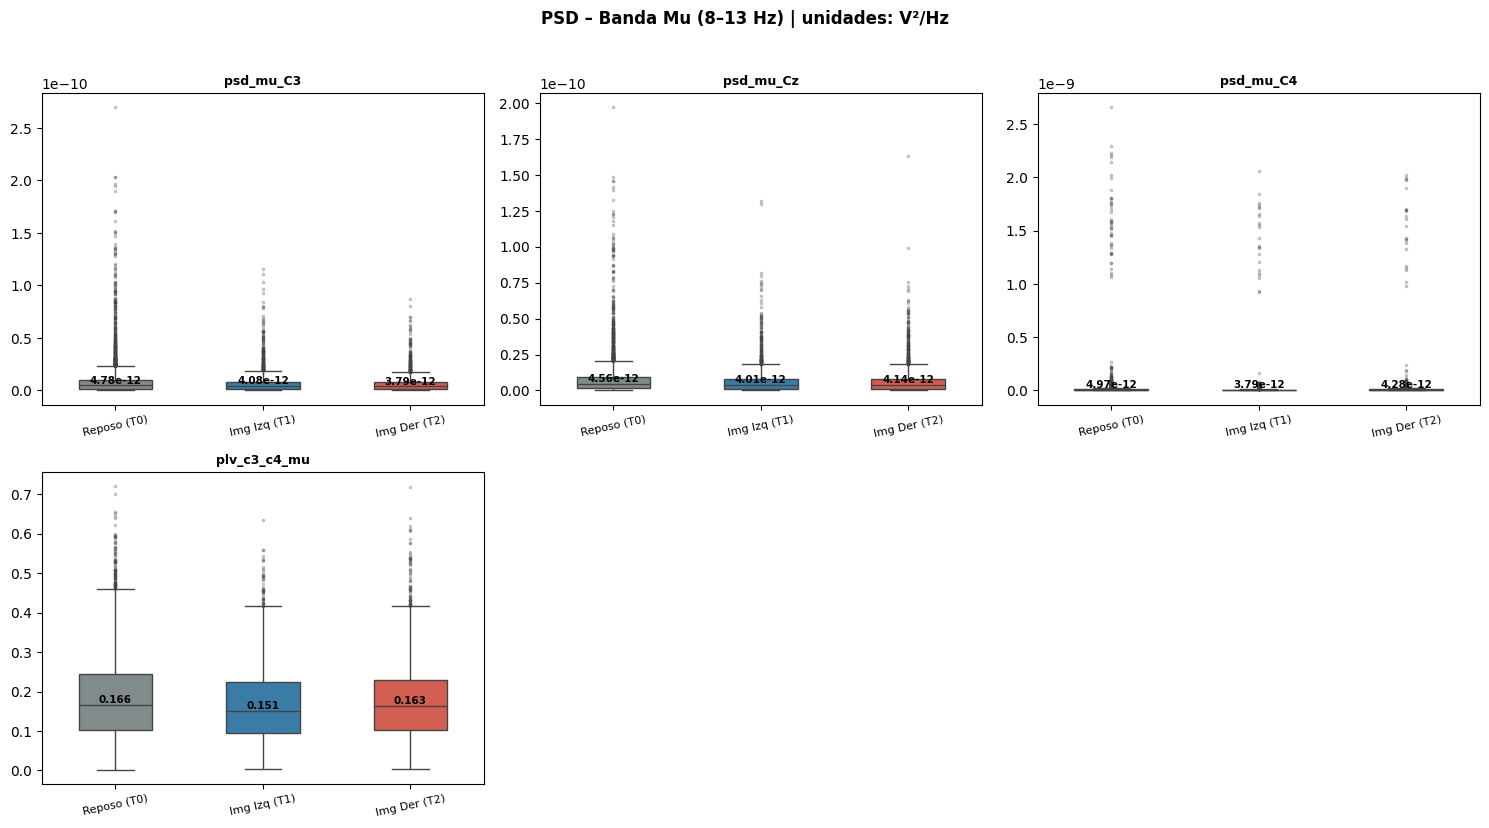

→ Figura guardada: figuras_P2/09a_boxplot_psd_mu.png


In [18]:
feats_mu = [c for c in cols_feat if 'mu' in c.lower()]
boxplot_grupo(
    feats_mu,
    'PSD – Banda Mu (8–13 Hz) | unidades: V²/Hz',
    '09a_boxplot_psd_mu.png',
    df_plot, orden, paleta
)

### **8.2 PSD – Banda Beta (13–30 Hz)**

La Beta complementa la Mu: también desincroniza durante imaginación motora
y su recuperación (Beta rebound) ocurre justo después del movimiento.

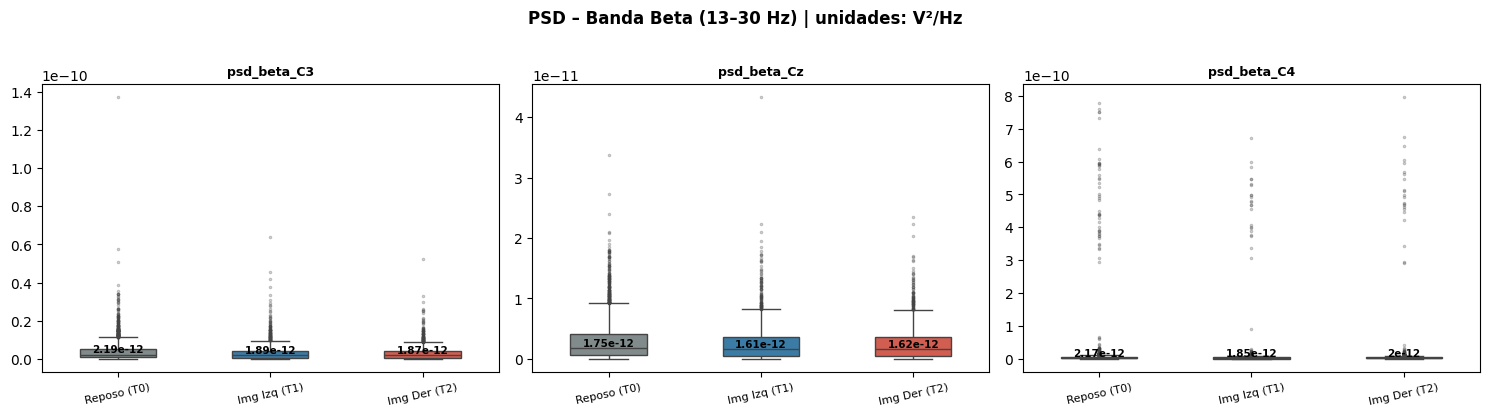

→ Figura guardada: figuras_P2/09b_boxplot_psd_beta.png


In [19]:
feats_beta = [c for c in cols_feat if 'beta' in c.lower()]
boxplot_grupo(
    feats_beta,
    'PSD – Banda Beta (13–30 Hz) | unidades: V²/Hz',
    '09b_boxplot_psd_beta.png',
    df_plot, orden, paleta
)

### **8.3 Parámetros de Hjorth (Actividad, Movilidad, Complejidad)**

Los tres parámetros están en escalas muy distintas entre sí,
por eso se grafican en celdas separadas del PSD.
- **Actividad**: varianza de la señal (potencia total)
- **Movilidad**: frecuencia media de la señal
- **Complejidad**: cuánto cambia la frecuencia en el tiempo

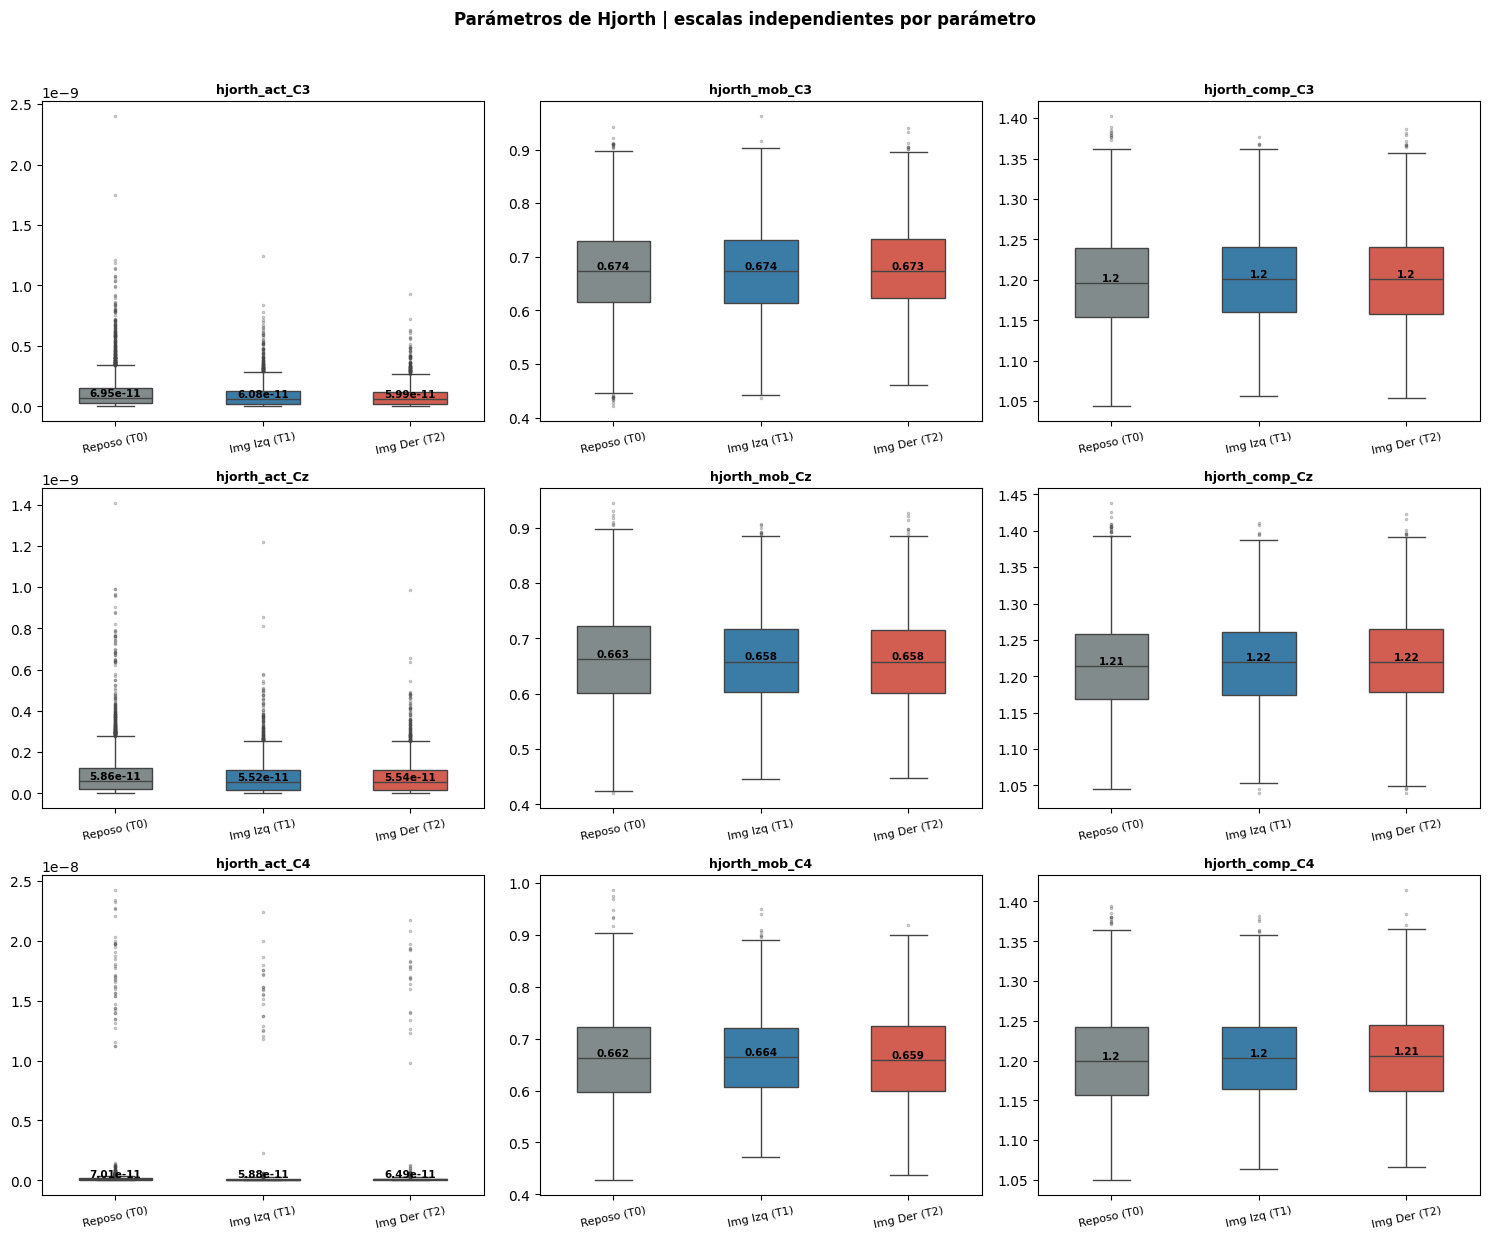

→ Figura guardada: figuras_P2/09c_boxplot_hjorth.png


In [20]:
feats_hjorth = [c for c in cols_feat if 'hjorth' in c.lower()]
boxplot_grupo(
    feats_hjorth,
    'Parámetros de Hjorth | escalas independientes por parámetro',
    '09c_boxplot_hjorth.png',
    df_plot, orden, paleta
)

### **8.4 Sample Entropy (entropía muestral)**

La SampEn mide la irregularidad de la señal (en nats).
En reposo la señal es más regular (ritmo Mu sincronizado → SampEn baja).
Durante imaginación motora el ritmo se desincroniza → SampEn sube.

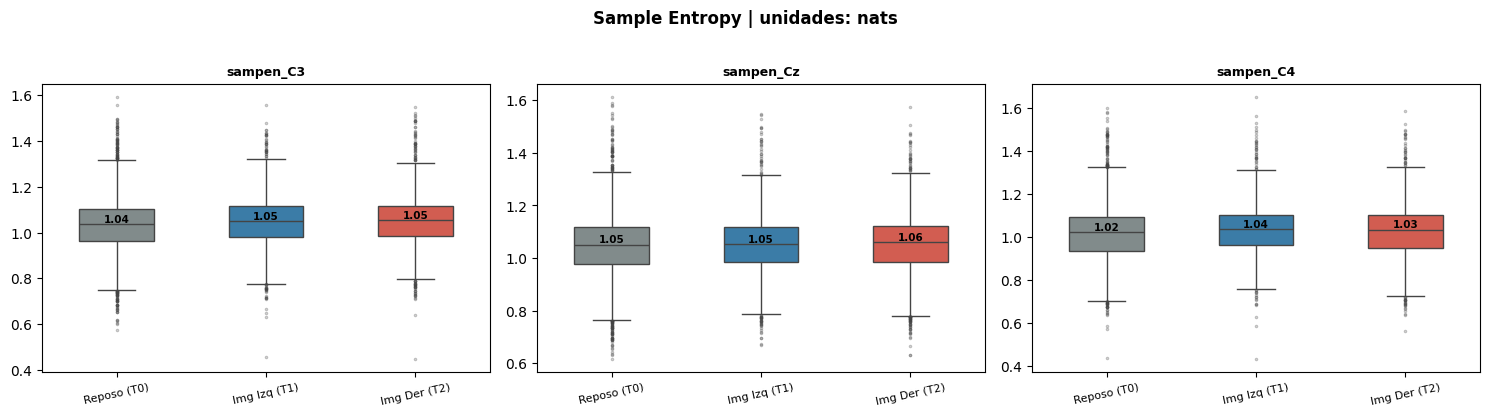

→ Figura guardada: figuras_P2/09d_boxplot_sampen.png


In [21]:
feats_se = [c for c in cols_feat if 'sampen' in c.lower() or 'entropy' in c.lower()]
boxplot_grupo(
    feats_se,
    'Sample Entropy | unidades: nats',
    '09d_boxplot_sampen.png',
    df_plot, orden, paleta
)

### **8.5 Phase Locking Value (PLV) entre C3 y C4**

El PLV mide la sincronía de fase entre los dos hemisferios.
Va de 0 (no sincronizados) a 1 (perfectamente sincronizados).
Durante imaginación unilateral se espera menor PLV porque el hemisferio
contralateral se desacopla del ipsilateral.

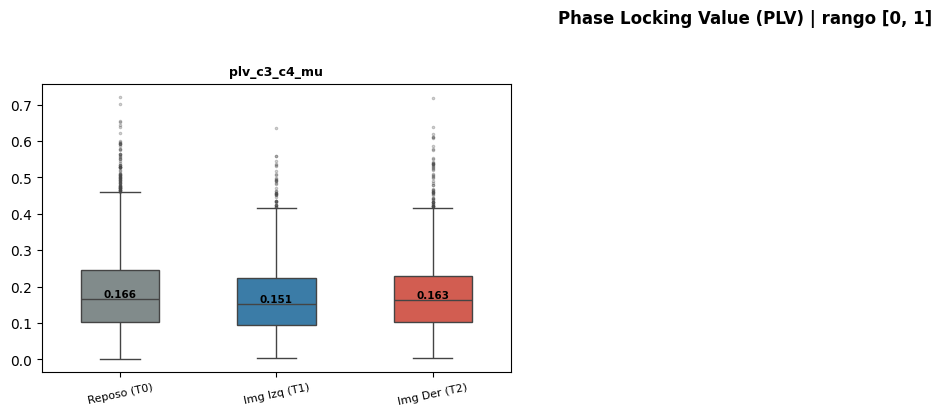

→ Figura guardada: figuras_P2/09e_boxplot_plv.png


In [22]:
feats_plv = [c for c in cols_feat if 'plv' in c.lower()]
boxplot_grupo(
    feats_plv,
    'Phase Locking Value (PLV) | rango [0, 1]',
    '09e_boxplot_plv.png',
    df_plot, orden, paleta
)


## **9. Pruebas de hipótesis estadísticas**




Para decidir qué características usar en los modelos, seguimos dos pasos:

**Paso A. Análisis detallados de las hipótesis del proyecto 1 (corrección con todos los sijetos) e hipótesis de clasificación**

Para las 4 comparaciones de interés neurofisiológico del proyecto 1 hacemos el flujo habitual:
1. Verificar normalidad con Shapiro-Wilk (o KS si N > 5000).
2. Si normal → t de Student | Si no normal → Mann-Whitney U.
3. Interpretar: p < 0.05 rechaza H₀.

**Paso B.Test global: Kruskal-Wallis sobre todas las características**
Aplicamos Kruskal-Wallis a las 19 características comparando los 3 grupos (T0, T1, T2).
- Es la versión no paramétrica del ANOVA → no asume normalidad.
- Si p < 0.05 → hay al menos un grupo diferente → la característica es útil para clasificar.
- Calculamos también el tamaño del efecto η² (eta cuadrado) para saber cuánto diferencia cada característica.
- Solo las características significativas entrarán a los modelos (requerimiento del proyecto).



#### **Paso A**
#### 1.Análisis detallados de las hipótesis del proyecto 1 

In [ ]:
####  Análisis 1. PSD Mu en C3: Imaginación Izquierda (T1) vs Imaginación Derecha (T2)

**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Mu entre el movimiento imaginario derecho e izquierdo en C3.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Mu entre el movimiento imaginario derecho e izquierdo en C3.


ANÁLISIS 1 — PSD Mu en C3: T1 (Izq) vs T2 (Der)
Shapiro T1 → p = 0.0000 | Shapiro T2 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 3105135.0000
p-value        : 0.031283
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


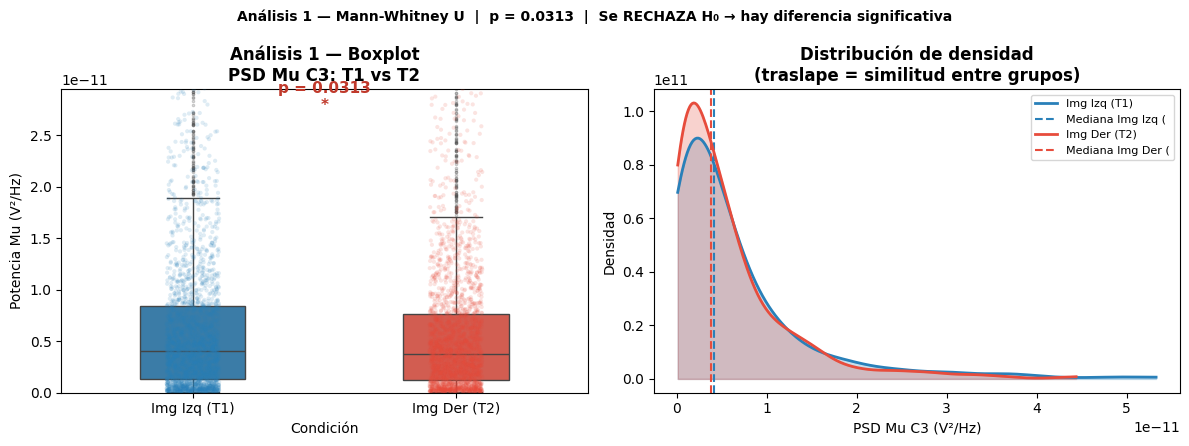

In [25]:
from scipy.stats import shapiro, mannwhitneyu, ttest_ind
import matplotlib.patches as mpatches

# Extraer los grupos de interés
mu_T1_C3 = df_features.loc[df_features['tarea'] == 1, 'psd_mu_C3'].dropna().values
mu_T2_C3 = df_features.loc[df_features['tarea'] == 2, 'psd_mu_C3'].dropna().values

# ── Paso 1: normalidad ───────────────────────────────────────────
# Con N > 5000 Shapiro-Wilk pierde sentido (detecta cualquier
# desviación ínfima como significativa). Usamos KS en ese caso.
from scipy.stats import kstest

def test_normalidad(grupo):
    if len(grupo) <= 5000:
        _, p = shapiro(grupo)
    else:
        _, p = kstest(grupo, 'norm', args=(grupo.mean(), grupo.std()))
    return p

p_norm_t1 = test_normalidad(mu_T1_C3)
p_norm_t2 = test_normalidad(mu_T2_C3)
normal = (p_norm_t1 > 0.05) and (p_norm_t2 > 0.05)

# ── Paso 2: prueba estadística ───────────────────────────────────
if normal:
    stat, p_val = ttest_ind(mu_T1_C3, mu_T2_C3)
    prueba_nombre = 't de Student'
else:
    stat, p_val = mannwhitneyu(mu_T1_C3, mu_T2_C3, alternative='two-sided')
    prueba_nombre = 'Mann-Whitney U'

# ── Paso 3: resultado ────────────────────────────────────────────
decision = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'

print('='*60)
print('ANÁLISIS 1 — PSD Mu en C3: T1 (Izq) vs T2 (Der)')
print('='*60)
print(f'Shapiro T1 → p = {p_norm_t1:.4f} | Shapiro T2 → p = {p_norm_t2:.4f}')
print(f'Prueba elegida : {prueba_nombre}')
print(f'Estadístico    : {stat:.4f}')
print(f'p-value        : {p_val:.6f}')
print(f'Conclusión     : {decision}')

# ── Gráfico de interpretación ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Boxplot
datos_bp = pd.DataFrame({
    'PSD Mu C3': np.concatenate([mu_T1_C3, mu_T2_C3]),
    'Condición': ['Img Izq (T1)']*len(mu_T1_C3) + ['Img Der (T2)']*len(mu_T2_C3)
})
sns.boxplot(data=datos_bp, x='Condición', y='PSD Mu C3',
            palette=[COLORES_CLASE[1], COLORES_CLASE[2]],
            ax=axes[0], width=0.4,
            flierprops=dict(marker='.', markersize=3, alpha=0.3))
sns.stripplot(data=datos_bp, x='Condición', y='PSD Mu C3',
              palette=[COLORES_CLASE[1], COLORES_CLASE[2]],
              ax=axes[0], alpha=0.15, size=3, jitter=True)
y_max = datos_bp['PSD Mu C3'].quantile(0.95)
axes[0].set_ylim(bottom=0, top=y_max * 1.25)
axes[0].annotate(f'p = {p_val:.4f}\n{"*" if p_val<0.05 else "ns"}',
                 xy=(0.5, 0.93), xycoords='axes fraction',
                 ha='center', fontsize=11,
                 color='#c0392b' if p_val < 0.05 else '#7f8c8d',
                 fontweight='bold')
axes[0].set_title('Análisis 1 — Boxplot\nPSD Mu C3: T1 vs T2', fontweight='bold')
axes[0].set_ylabel('Potencia Mu (V²/Hz)')

# Panel B: Distribución de densidad
from scipy.stats import gaussian_kde
for datos, label, color in [
        (mu_T1_C3, 'Img Izq (T1)', COLORES_CLASE[1]),
        (mu_T2_C3, 'Img Der (T2)', COLORES_CLASE[2])]:
    lim = np.percentile(datos, [1, 99])
    xs  = np.linspace(lim[0], lim[1], 300)
    kde = gaussian_kde(datos)
    axes[1].fill_between(xs, kde(xs), alpha=0.25, color=color)
    axes[1].plot(xs, kde(xs), color=color, lw=2, label=label)
    axes[1].axvline(np.median(datos), color=color, ls='--', lw=1.5,
                    label=f'Mediana {label[:9]}')
axes[1].set_xlabel('PSD Mu C3 (V²/Hz)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de densidad\n(traslape = similitud entre grupos)', fontweight='bold')
axes[1].legend(fontsize=8)

fig.suptitle(f'Análisis 1 — {prueba_nombre}  |  p = {p_val:.4f}  |  {decision}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_01_mu_C3_T1vsT2.png', dpi=150, bbox_inches='tight')
plt.show()



### Análisis 2. PSD Beta en C4: Imaginación Izquierda (T1) vs Imaginación Derecha (T2)

**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Beta entre el movimiento imaginario derecho e izquierdo en C4.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Beta entre el movimiento imaginario derecho e izquierdo en C4.


ANÁLISIS 2 — PSD Beta en C4: T1 (Izq) vs T2 (Der)
Shapiro T1 → p = 0.0000 | Shapiro T2 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 2865237.0000
p-value        : 0.007042
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


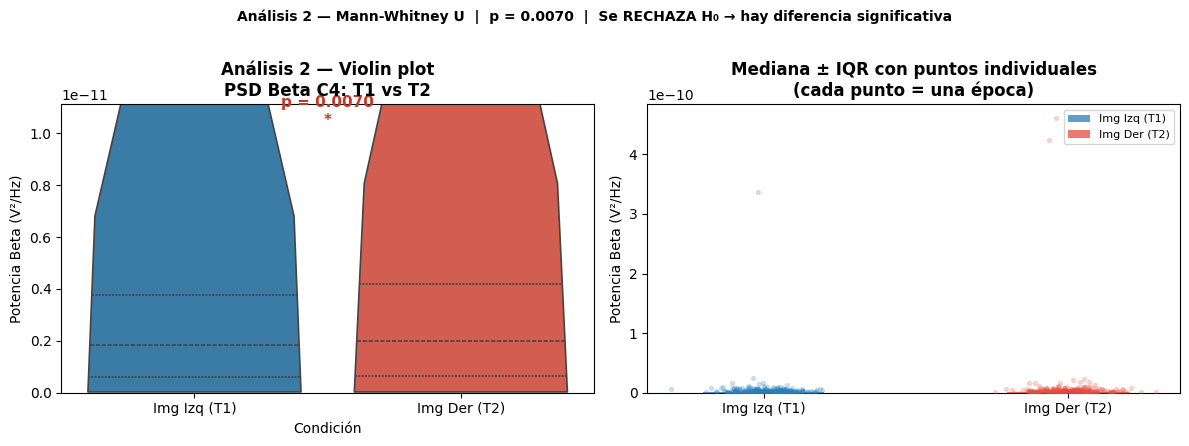

In [26]:
# Extraer grupos
beta_T1_C4 = df_features.loc[df_features['tarea'] == 1, 'psd_beta_C4'].dropna().values
beta_T2_C4 = df_features.loc[df_features['tarea'] == 2, 'psd_beta_C4'].dropna().values

# ── Normalidad ───────────────────────────────────────────────────
p_n1 = test_normalidad(beta_T1_C4)
p_n2 = test_normalidad(beta_T2_C4)
normal2  = (p_n1 > 0.05) and (p_n2 > 0.05)

# ── Prueba ───────────────────────────────────────────────────────
if normal2:
    stat2, p_val2 = ttest_ind(beta_T1_C4, beta_T2_C4)
    prueba2 = 't de Student'
else:
    stat2, p_val2 = mannwhitneyu(beta_T1_C4, beta_T2_C4, alternative='two-sided')
    prueba2 = 'Mann-Whitney U'

decision2 = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val2 < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'

print('='*60)
print('ANÁLISIS 2 — PSD Beta en C4: T1 (Izq) vs T2 (Der)')
print('='*60)
print(f'Shapiro T1 → p = {p_n1:.4f} | Shapiro T2 → p = {p_n2:.4f}')
print(f'Prueba elegida : {prueba2}')
print(f'Estadístico    : {stat2:.4f}')
print(f'p-value        : {p_val2:.6f}')
print(f'Conclusión     : {decision2}')

# ── Gráfico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Boxplot + violin
datos_bp2 = pd.DataFrame({
    'PSD Beta C4': np.concatenate([beta_T1_C4, beta_T2_C4]),
    'Condición': ['Img Izq (T1)']*len(beta_T1_C4) + ['Img Der (T2)']*len(beta_T2_C4)
})
sns.violinplot(data=datos_bp2, x='Condición', y='PSD Beta C4',
               palette=[COLORES_CLASE[1], COLORES_CLASE[2]],
               ax=axes[0], inner='quartile', cut=0, linewidth=1.2)
y_max2 = datos_bp2['PSD Beta C4'].quantile(0.95)
axes[0].set_ylim(bottom=0, top=y_max2 * 1.25)
axes[0].annotate(f'p = {p_val2:.4f}\n{"*" if p_val2<0.05 else "ns"}',
                 xy=(0.5, 0.93), xycoords='axes fraction',
                 ha='center', fontsize=11,
                 color='#c0392b' if p_val2 < 0.05 else '#7f8c8d',
                 fontweight='bold')
axes[0].set_title('Análisis 2 — Violin plot\nPSD Beta C4: T1 vs T2', fontweight='bold')
axes[0].set_ylabel('Potencia Beta (V²/Hz)')

# Panel B: Barras de media ± std con puntos individuales
grupos_plot = [beta_T1_C4, beta_T2_C4]
labels_plot = ['Img Izq (T1)', 'Img Der (T2)']
colores_plot = [COLORES_CLASE[1], COLORES_CLASE[2]]
medias = [np.median(g) for g in grupos_plot]
q25    = [np.percentile(g, 25) for g in grupos_plot]
q75    = [np.percentile(g, 75) for g in grupos_plot]

for j, (g, lab, col, med, q2, q7) in enumerate(
        zip(grupos_plot, labels_plot, colores_plot, medias, q25, q75)):
    axes[1].bar(j, med, color=col, alpha=0.75, width=0.4, label=lab)
    axes[1].errorbar(j, med, yerr=[[med-q2], [q7-med]],
                     fmt='none', color='black', capsize=6, lw=2)
    # Puntos individuales (muestra)
    n_pts = min(300, len(g))
    idx_s = np.random.choice(len(g), n_pts, replace=False)
    axes[1].scatter(np.random.normal(j, 0.08, n_pts), g[idx_s],
                    color=col, alpha=0.2, s=8, zorder=3)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels_plot)
axes[1].set_ylabel('Potencia Beta (V²/Hz)')
axes[1].set_title('Mediana ± IQR con puntos individuales\n(cada punto = una época)', fontweight='bold')
axes[1].legend(fontsize=8)

fig.suptitle(f'Análisis 2 — {prueba2}  |  p = {p_val2:.4f}  |  {decision2}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_02_beta_C4_T1vsT2.png', dpi=150, bbox_inches='tight')
plt.show()



### **Análisis 3a.** PSD Mu en C3: Imaginación Derecha (T2) vs Reposo (T0)


**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano derecha en C3 y
el estado de reposo.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano derecha en C3 y
el estado de reposo.


ANÁLISIS 3a — PSD Mu en C3: T2 (Img Der) vs T0 (Reposo)
Shapiro T2 → p = 0.0000 | Shapiro T0 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 5281001.0000
p-value        : 0.000000
Dirección ERD  : T2 < T0 (ERD confirmado ✓)
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


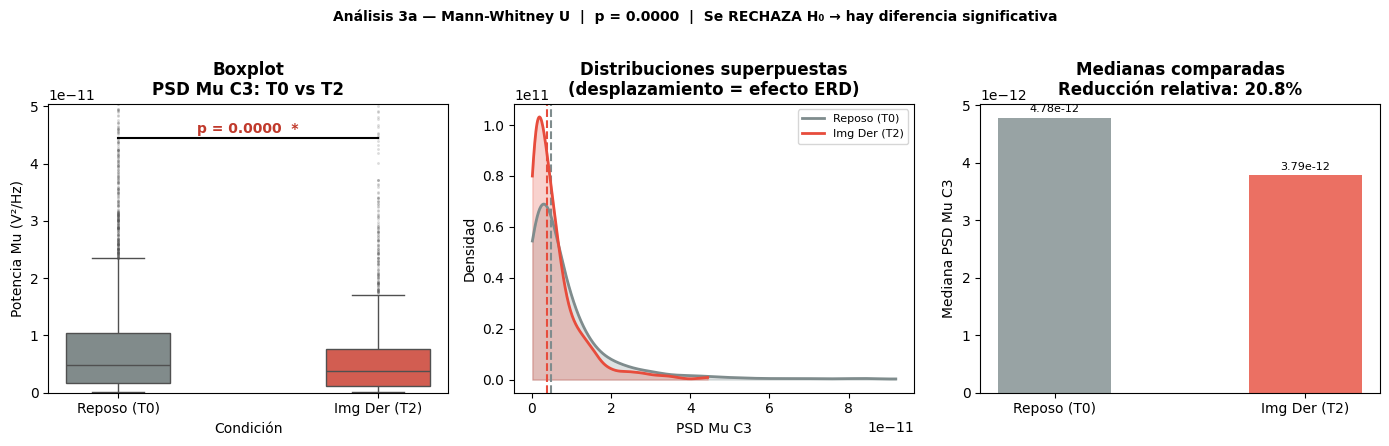

In [27]:
# Grupos: T2 (imaginación derecha) vs T0 (reposo) — PSD Mu en C3
mu_T2_C3 = df_features.loc[df_features['tarea'] == 2, 'psd_mu_C3'].dropna().values
mu_T0_C3 = df_features.loc[df_features['tarea'] == 0, 'psd_mu_C3'].dropna().values

# ── Normalidad ───────────────────────────────────────────────────
p_n_t2 = test_normalidad(mu_T2_C3)
p_n_t0 = test_normalidad(mu_T0_C3)
normal3a  = (p_n_t2 > 0.05) and (p_n_t0 > 0.05)

# ── Prueba ───────────────────────────────────────────────────────
if normal3a:
    stat3a, p_val3a = ttest_ind(mu_T2_C3, mu_T0_C3)
    prueba3a = 't de Student'
else:
    stat3a, p_val3a = mannwhitneyu(mu_T2_C3, mu_T0_C3, alternative='two-sided')
    prueba3a = 'Mann-Whitney U'

decision3a = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val3a < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'

# Dirección del efecto (esperamos T2 < T0 por ERD)
dir_efecto = 'T2 < T0 (ERD confirmado ✓)' if np.median(mu_T2_C3) < np.median(mu_T0_C3) else 'T2 ≥ T0 (ERD no observado)'

print('='*60)
print('ANÁLISIS 3a — PSD Mu en C3: T2 (Img Der) vs T0 (Reposo)')
print('='*60)
print(f'Shapiro T2 → p = {p_n_t2:.4f} | Shapiro T0 → p = {p_n_t0:.4f}')
print(f'Prueba elegida : {prueba3a}')
print(f'Estadístico    : {stat3a:.4f}')
print(f'p-value        : {p_val3a:.6f}')
print(f'Dirección ERD  : {dir_efecto}')
print(f'Conclusión     : {decision3a}')

# ── Gráfico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel A: Boxplot comparativo
datos_3a = pd.DataFrame({
    'PSD Mu C3': np.concatenate([mu_T0_C3, mu_T2_C3]),
    'Condición': ['Reposo (T0)']*len(mu_T0_C3) + ['Img Der (T2)']*len(mu_T2_C3)
})
sns.boxplot(data=datos_3a, x='Condición', y='PSD Mu C3',
            order=['Reposo (T0)', 'Img Der (T2)'],
            palette=[COLORES_CLASE[0], COLORES_CLASE[2]],
            ax=axes[0], width=0.4,
            flierprops=dict(marker='.', markersize=2, alpha=0.2))
y_lim3a = datos_3a['PSD Mu C3'].quantile(0.97)
axes[0].set_ylim(0, y_lim3a * 1.25)
# Línea de comparación con p-value
y_bar = y_lim3a * 1.10
axes[0].plot([0, 1], [y_bar, y_bar], 'k-', lw=1.5)
axes[0].text(0.5, y_bar * 1.02,
             f'p = {p_val3a:.4f}  {"*" if p_val3a<0.05 else "ns"}',
             ha='center', fontsize=10,
             color='#c0392b' if p_val3a < 0.05 else '#7f8c8d', fontweight='bold')
axes[0].set_title('Boxplot\nPSD Mu C3: T0 vs T2', fontweight='bold')
axes[0].set_ylabel('Potencia Mu (V²/Hz)')

# Panel B: Distribuciones superpuestas
for datos, label, color in [
        (mu_T0_C3, 'Reposo (T0)', COLORES_CLASE[0]),
        (mu_T2_C3, 'Img Der (T2)', COLORES_CLASE[2])]:
    lim = np.percentile(datos, [1, 99])
    xs  = np.linspace(lim[0], lim[1], 300)
    kde = gaussian_kde(datos)
    axes[1].fill_between(xs, kde(xs), alpha=0.25, color=color)
    axes[1].plot(xs, kde(xs), color=color, lw=2, label=label)
    axes[1].axvline(np.median(datos), color=color, ls='--', lw=1.5)
axes[1].set_xlabel('PSD Mu C3')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribuciones superpuestas\n(desplazamiento = efecto ERD)', fontweight='bold')
axes[1].legend(fontsize=8)

# Panel C: Medianas con reducción relativa
med_t0 = np.median(mu_T0_C3)
med_t2 = np.median(mu_T2_C3)
reduccion = (med_t0 - med_t2) / med_t0 * 100
barras = axes[2].bar(['Reposo (T0)', 'Img Der (T2)'],
                     [med_t0, med_t2],
                     color=[COLORES_CLASE[0], COLORES_CLASE[2]],
                     alpha=0.8, width=0.45)
for bar, val in zip(barras, [med_t0, med_t2]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.02,
                 f'{val:.2e}', ha='center', fontsize=8)
axes[2].set_ylabel('Mediana PSD Mu C3')
axes[2].set_title(f'Medianas comparadas\nReducción relativa: {reduccion:.1f}%', fontweight='bold')

fig.suptitle(f'Análisis 3a — {prueba3a}  |  p = {p_val3a:.4f}  |  {decision3a}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_03a_mu_C3_T2vsT0.png', dpi=150, bbox_inches='tight')
plt.show()



### **Análisis 3b.** PSD Mu en C3: Imaginación Izquierda (T1) vs Reposo (T0)


**H₀:** No existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano izquierda en C3 y
el estado de reposo.

**H₁:** Existen diferencias significativas en la potencia espectral de la
banda Mu entre la imaginación de movimiento de la mano izquierda en C3 y
el estado de reposo.


ANÁLISIS 3b — PSD Mu en C3: T1 (Img Izq) vs T0 (Reposo)
Shapiro T1 → p = 0.0000 | Shapiro T0 → p = 0.0000
Prueba elegida : Mann-Whitney U
Estadístico    : 5589783.0000
p-value        : 0.000000
Dirección ERD  : T1 < T0 (ERD en C3 ipsilateral)
Conclusión     : Se RECHAZA H₀ → hay diferencia significativa


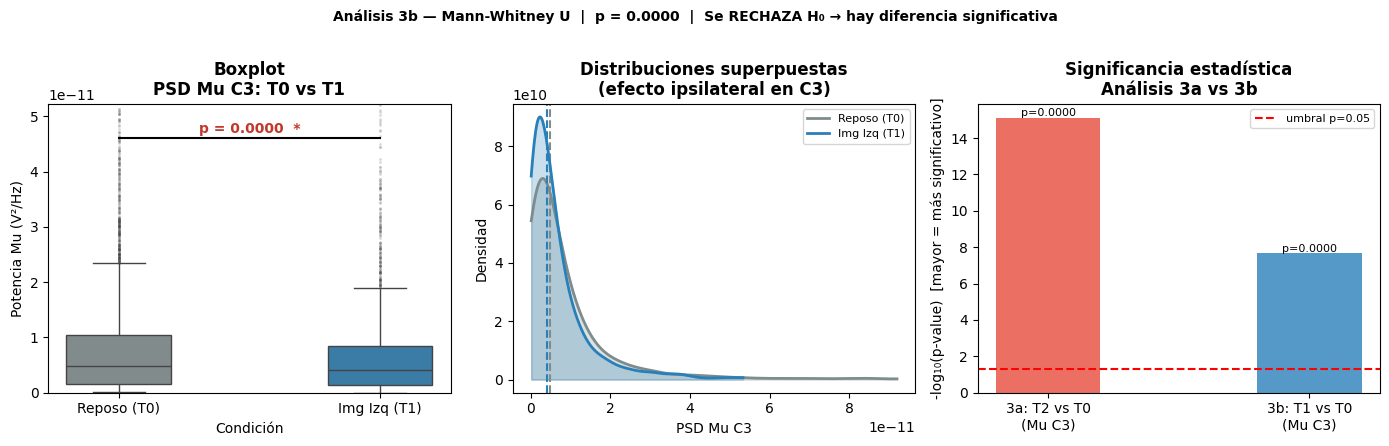

In [28]:
# Grupos: T1 (imaginación izquierda) vs T0 (reposo) — PSD Mu en C3
# mu_T1_C3 ya está calculado en Análisis 1
# mu_T0_C3 ya está calculado en Análisis 3a

# ── Normalidad ───────────────────────────────────────────────────
p_n_t1_3b = test_normalidad(mu_T1_C3)
p_n_t0_3b = test_normalidad(mu_T0_C3)
normal3b      = (p_n_t1_3b > 0.05) and (p_n_t0_3b > 0.05)

# ── Prueba ───────────────────────────────────────────────────────
if normal3b:
    stat3b, p_val3b = ttest_ind(mu_T1_C3, mu_T0_C3)
    prueba3b = 't de Student'
else:
    stat3b, p_val3b = mannwhitneyu(mu_T1_C3, mu_T0_C3, alternative='two-sided')
    prueba3b = 'Mann-Whitney U'

decision3b = 'Se RECHAZA H₀ → hay diferencia significativa' if p_val3b < 0.05 else 'No se rechaza H₀ → no hay diferencia significativa'
dir_efecto3b = 'T1 < T0 (ERD en C3 ipsilateral)' if np.median(mu_T1_C3) < np.median(mu_T0_C3) else 'T1 ≥ T0 (sin ERD en C3 ipsilateral)'

print('='*60)
print('ANÁLISIS 3b — PSD Mu en C3: T1 (Img Izq) vs T0 (Reposo)')
print('='*60)
print(f'Shapiro T1 → p = {p_n_t1_3b:.4f} | Shapiro T0 → p = {p_n_t0_3b:.4f}')
print(f'Prueba elegida : {prueba3b}')
print(f'Estadístico    : {stat3b:.4f}')
print(f'p-value        : {p_val3b:.6f}')
print(f'Dirección ERD  : {dir_efecto3b}')
print(f'Conclusión     : {decision3b}')

# ── Gráfico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel A: Boxplot
datos_3b = pd.DataFrame({
    'PSD Mu C3': np.concatenate([mu_T0_C3, mu_T1_C3]),
    'Condición': ['Reposo (T0)']*len(mu_T0_C3) + ['Img Izq (T1)']*len(mu_T1_C3)
})
sns.boxplot(data=datos_3b, x='Condición', y='PSD Mu C3',
            order=['Reposo (T0)', 'Img Izq (T1)'],
            palette=[COLORES_CLASE[0], COLORES_CLASE[1]],
            ax=axes[0], width=0.4,
            flierprops=dict(marker='.', markersize=2, alpha=0.2))
y_lim3b = datos_3b['PSD Mu C3'].quantile(0.97)
axes[0].set_ylim(0, y_lim3b * 1.25)
y_bar3b = y_lim3b * 1.10
axes[0].plot([0, 1], [y_bar3b, y_bar3b], 'k-', lw=1.5)
axes[0].text(0.5, y_bar3b * 1.02,
             f'p = {p_val3b:.4f}  {"*" if p_val3b<0.05 else "ns"}',
             ha='center', fontsize=10,
             color='#c0392b' if p_val3b < 0.05 else '#7f8c8d', fontweight='bold')
axes[0].set_title('Boxplot\nPSD Mu C3: T0 vs T1', fontweight='bold')
axes[0].set_ylabel('Potencia Mu (V²/Hz)')

# Panel B: Distribuciones superpuestas
for datos, label, color in [
        (mu_T0_C3, 'Reposo (T0)', COLORES_CLASE[0]),
        (mu_T1_C3, 'Img Izq (T1)', COLORES_CLASE[1])]:
    lim = np.percentile(datos, [1, 99])
    xs  = np.linspace(lim[0], lim[1], 300)
    kde = gaussian_kde(datos)
    axes[1].fill_between(xs, kde(xs), alpha=0.25, color=color)
    axes[1].plot(xs, kde(xs), color=color, lw=2, label=label)
    axes[1].axvline(np.median(datos), color=color, ls='--', lw=1.5)
axes[1].set_xlabel('PSD Mu C3')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribuciones superpuestas\n(efecto ipsilateral en C3)', fontweight='bold')
axes[1].legend(fontsize=8)

# Panel C: Comparación directa A1 vs A3a vs A3b (resumen de los 4 análisis)
resumen_labels = ['3a: T2 vs T0\n(Mu C3)', '3b: T1 vs T0\n(Mu C3)']
resumen_pvals  = [p_val3a, p_val3b]
resumen_stats  = [stat3a, stat3b]
barras_res = axes[2].bar(resumen_labels, [-np.log10(p+1e-300) for p in resumen_pvals],
                         color=[COLORES_CLASE[2], COLORES_CLASE[1]], alpha=0.8, width=0.4)
axes[2].axhline(-np.log10(0.05), ls='--', color='red', lw=1.5, label='umbral p=0.05')
axes[2].set_ylabel('-log₁₀(p-value)  [mayor = más significativo]')
axes[2].set_title('Significancia estadística\nAnálisis 3a vs 3b', fontweight='bold')
axes[2].legend(fontsize=8)
for bar, pv in zip(barras_res, resumen_pvals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'p={pv:.4f}', ha='center', fontsize=8)

fig.suptitle(f'Análisis 3b — {prueba3b}  |  p = {p_val3b:.4f}  |  {decision3b}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_03b_mu_C3_T1vsT0.png', dpi=150, bbox_inches='tight')
plt.show()


---
##### Resumen general de los 4 análisis de hipótesis

Esta celda consolida los resultados de los 4 análisis y nos da una vista
rápida de la existencia de diferencias significativas en las fases de interés.


RESUMEN DE HIPÓTESIS
Análisis    Variable   Grupos         Prueba  Estadístico  p-value   Decisión
       1   PSD Mu C3 T1 vs T2 Mann-Whitney U    3105135.0 0.031283 Rechaza H₀
       2 PSD Beta C4 T1 vs T2 Mann-Whitney U    2865237.0 0.007042 Rechaza H₀
      3a   PSD Mu C3 T2 vs T0 Mann-Whitney U    5281001.0 0.000000 Rechaza H₀
      3b   PSD Mu C3 T1 vs T0 Mann-Whitney U    5589783.0 0.000000 Rechaza H₀


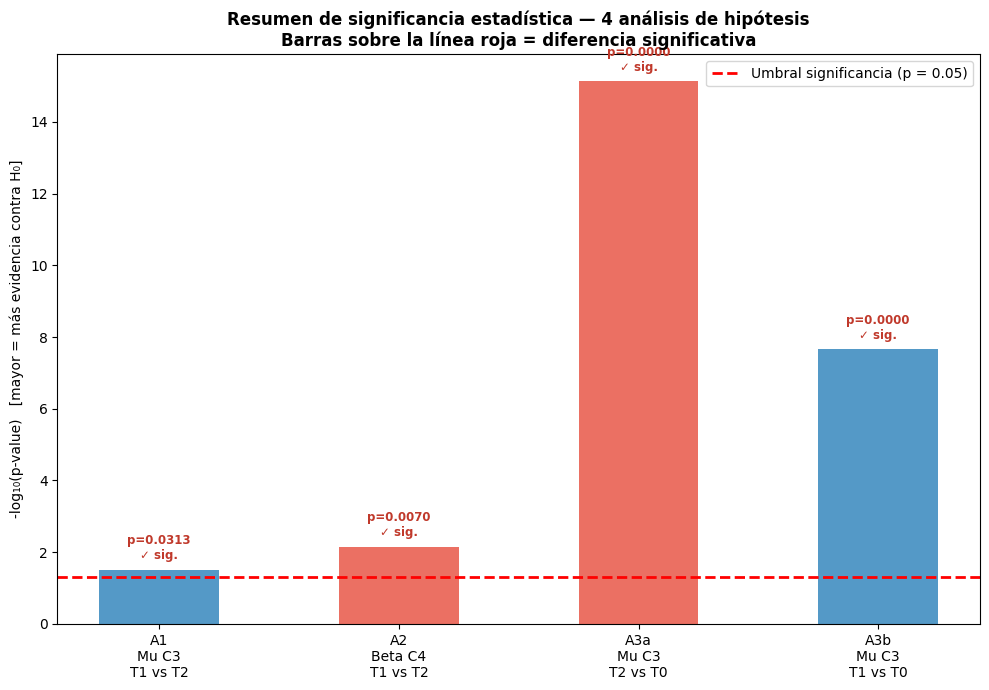


CARACTERÍSTICAS SELECCIONADAS PARA LOS MODELOS
Total disponibles : 19
Significativas    : 16
  psd_mu_C3                      eta²=0.0074  p=0.000000
  psd_beta_C3                    eta²=0.0047  p=0.000000
  hjorth_act_C3                  eta²=0.0055  p=0.000000
  hjorth_act_C4                  eta²=0.0053  p=0.000000
  psd_beta_C4                    eta²=0.0038  p=0.000000
  sampen_C3                      eta²=0.0056  p=0.000000
  psd_mu_C4                      eta²=0.0085  p=0.000000
  sampen_C4                      eta²=0.0040  p=0.000000
  plv_c3_c4_mu                   eta²=0.0025  p=0.000002
  psd_mu_Cz                      eta²=0.0023  p=0.000004
  psd_beta_Cz                    eta²=0.0018  p=0.000062
  hjorth_act_Cz                  eta²=0.0017  p=0.000106
  hjorth_comp_Cz                 eta²=0.0012  p=0.000822
  hjorth_comp_C3                 eta²=0.0005  p=0.028378
  hjorth_mob_C4                  eta²=0.0005  p=0.035090
  sampen_Cz                      eta²=0.0005  p=0.0

In [ ]:
# Tabla resumen
tabla_hipotesis = pd.DataFrame([
    {'Análisis': '1',
     'Variable': 'PSD Mu C3',
     'Grupos': 'T1 vs T2',
     'Prueba': prueba_nombre,
     'Estadístico': round(stat, 4),
     'p-value': round(p_val, 6),
     'Decisión': 'Rechaza H₀' if p_val < 0.05 else 'No rechaza H₀'},
    {'Análisis': '2',
     'Variable': 'PSD Beta C4',
     'Grupos': 'T1 vs T2',
     'Prueba': prueba2,
     'Estadístico': round(stat2, 4),
     'p-value': round(p_val2, 6),
     'Decisión': 'Rechaza H₀' if p_val2 < 0.05 else 'No rechaza H₀'},
    {'Análisis': '3a',
     'Variable': 'PSD Mu C3',
     'Grupos': 'T2 vs T0',
     'Prueba': prueba3a,
     'Estadístico': round(stat3a, 4),
     'p-value': round(p_val3a, 6),
     'Decisión': 'Rechaza H₀' if p_val3a < 0.05 else 'No rechaza H₀'},
    {'Análisis': '3b',
     'Variable': 'PSD Mu C3',
     'Grupos': 'T1 vs T0',
     'Prueba': prueba3b,
     'Estadístico': round(stat3b, 4),
     'p-value': round(p_val3b, 6),
     'Decisión': 'Rechaza H₀' if p_val3b < 0.05 else 'No rechaza H₀'},
])

print('RESUMEN DE HIPÓTESIS')
print('='*80)
print(tabla_hipotesis.to_string(index=False))

# ── Gráfico resumen: -log10(p) de los 4 análisis ─────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
etiquetas = [
    'A1\nMu C3\nT1 vs T2',
    'A2\nBeta C4\nT1 vs T2',
    'A3a\nMu C3\nT2 vs T0',
    'A3b\nMu C3\nT1 vs T0'
]
pvals_todos = [p_val, p_val2, p_val3a, p_val3b]
colores_res = [COLORES_CLASE[1], COLORES_CLASE[2], COLORES_CLASE[2], COLORES_CLASE[1]]
log_p = [-np.log10(p + 1e-300) for p in pvals_todos]

bars = ax.bar(etiquetas, log_p, color=colores_res, alpha=0.8, width=0.5)
ax.axhline(-np.log10(0.05), color='red', ls='--', lw=2,
            label='Umbral significancia (p = 0.05)')

for bar, pv in zip(bars, pvals_todos):
    label_p = f'p={pv:.4f}\n{"✓ sig." if pv<0.05 else "ns"}'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            label_p, ha='center', fontsize=8.5,
            color='#c0392b' if pv < 0.05 else '#7f8c8d',
            fontweight='bold')

ax.set_ylabel('-log₁₀(p-value)   [mayor = más evidencia contra H₀]')
ax.set_title('Resumen de significancia estadística — 4 análisis de hipótesis\n'
             'Barras sobre la línea roja = diferencia significativa',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_resumen_4analisis.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Resumen de características que entran al modelo ─────────────
print('\n' + '='*60)
print('CARACTERÍSTICAS SELECCIONADAS PARA LOS MODELOS')
print('='*60)
print(f'Total disponibles : {len(cols_feat)}')
print(f'Significativas    : {len(feats_significativas)}')
for f in feats_significativas:
    eta = resultados_kw[f]['eta2']
    p   = resultados_kw[f]['p_value']
    print(f'  {f:<30} eta²={eta:.4f}  p={p:.6f}')


---
#### Paso A

#### **2.Hipótesis sobre índices nuevos: Hjorth, Sample Entropy y PLV**

Estas hipótesis complementan las del Proyecto 1 (PSD) con los tres índices
nuevos que extrajimos en este proyecto. El objetivo es demostrar que cada
uno discrimina entre las condiciones y por eso tiene sentido usarlo como
feature en el clasificador.

Para cada par de grupos usamos el mismo flujo:
- **Shapiro-Wilk** (o KS si N > 5000) para verificar normalidad.
- Si normal → **t de Student**; si no → **Mann-Whitney U**.

Al final, un resumen conjunto de las 13 hipótesis del proyecto.



### Hipótesis 1 — Hjorth Movilidad en C3

La Movilidad de Hjorth captura la frecuencia media de la señal.
Si el ERD modifica la banda Mu durante la imaginación motora,
la frecuencia dominante de C3 debería cambiar entre condiciones.

| Sub-hipótesis | Grupos | Pregunta |
| --- | --- | --- |
| **1a** | T1 vs T2 | **H₀:** No existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **1b** | T2 vs T0 | **H₀:** No existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **1c** | T1 vs T0 | **H₀:** No existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la Movilidad de Hjorth del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |


H 5a | T1 vs T2     | Mann-Whitney U  | p=0.499239 | No rechaza H₀
H 5b | T2 vs T0     | Mann-Whitney U  | p=0.092347 | No rechaza H₀
H 5c | T1 vs T0     | Mann-Whitney U  | p=0.314723 | No rechaza H₀


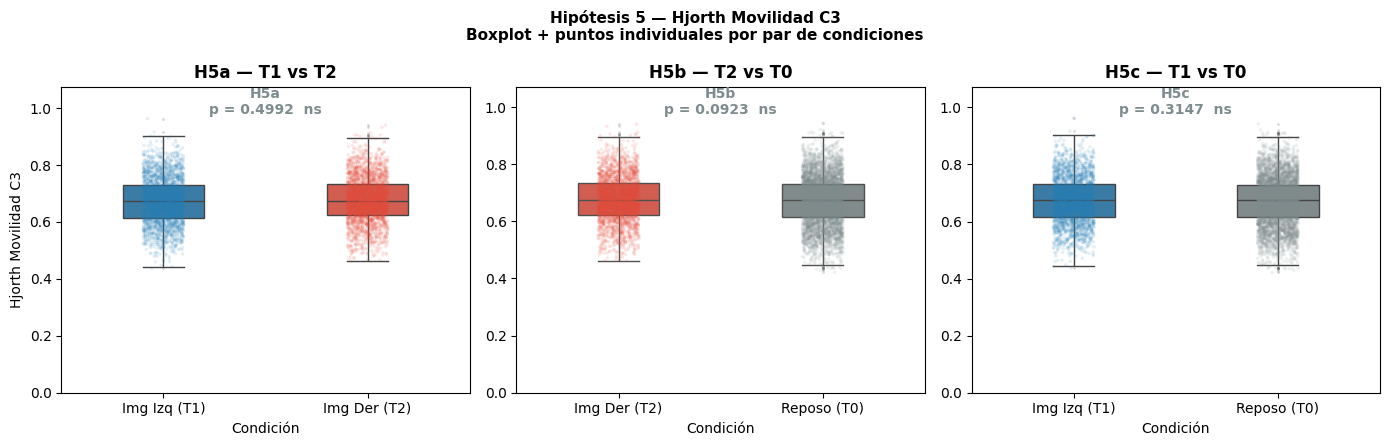

In [34]:
# ── Extraer grupos: Hjorth Movilidad C3 ────────────────────────
mob_T0 = df_features.loc[df_features['tarea'] == 0, 'hjorth_mob_C3'].dropna().values
mob_T1 = df_features.loc[df_features['tarea'] == 1, 'hjorth_mob_C3'].dropna().values
mob_T2 = df_features.loc[df_features['tarea'] == 2, 'hjorth_mob_C3'].dropna().values

# ── Función reutilizable para prueba pareada ─────────────────────
def prueba_dos_grupos(g1, g2, nombre1, nombre2, variable, analisis_id):
    """
    Aplica Shapiro/KS, elige t-Student o Mann-Whitney y devuelve dict de resultados.
    """
    from scipy.stats import shapiro, mannwhitneyu, ttest_ind, kstest

    def test_norm(g):
        if len(g) <= 5000:
            _, p = shapiro(g)
        else:
            _, p = kstest((g - g.mean()) / g.std(), 'norm')
        return p

    p_n1 = test_norm(g1)
    p_n2 = test_norm(g2)
    normal = (p_n1 > 0.05) and (p_n2 > 0.05)

    if normal:
        stat, p_val = ttest_ind(g1, g2)
        prueba = 't de Student'
    else:
        stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
        prueba = 'Mann-Whitney U'

    return {
        'id': analisis_id, 'variable': variable,
        'grupos': f'{nombre1} vs {nombre2}',
        'prueba': prueba, 'stat': round(stat, 4),
        'p_value': round(p_val, 6),
        'decision': 'Rechaza H₀' if p_val < 0.05 else 'No rechaza H₀',
        'p_norm_g1': round(p_n1, 4), 'p_norm_g2': round(p_n2, 4)
    }

# ── Tres sub-hipótesis ───────────────────────────────────────────
res_5a = prueba_dos_grupos(mob_T1, mob_T2, 'T1', 'T2', 'Hjorth Mob C3', '5a')
res_5b = prueba_dos_grupos(mob_T2, mob_T0, 'T2', 'T0', 'Hjorth Mob C3', '5b')
res_5c = prueba_dos_grupos(mob_T1, mob_T0, 'T1', 'T0', 'Hjorth Mob C3', '5c')

for r in [res_5a, res_5b, res_5c]:
    print(f"H {r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# ── Gráfico ──────────────────────────────────────────────────────
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares = [
    (mob_T1, mob_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_5a, '5a'),
    (mob_T2, mob_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_5b, '5b'),
    (mob_T1, mob_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_5c, '5c'),
]

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares):
    df_bp = pd.DataFrame({
        'Hjorth Mob C3': np.concatenate([ga, gb]),
        'Condición': [NOMBRES_CLASE[{'T0':0,'T1':1,'T2':2}[la]]]*len(ga) +
                     [NOMBRES_CLASE[{'T0':0,'T1':1,'T2':2}[lb]]]*len(gb)
    })
    sns.boxplot(data=df_bp, x='Condición', y='Hjorth Mob C3',
                palette=[ca, cb], ax=ax, width=0.4,
                flierprops=dict(marker='.', markersize=2, alpha=0.2))
    sns.stripplot(data=df_bp, x='Condición', y='Hjorth Mob C3',
                  palette=[ca, cb], ax=ax, alpha=0.12, size=2.5, jitter=True)
    ylim = df_bp['Hjorth Mob C3'].quantile(0.97)
    ax.set_ylim(0, ylim * 1.3)
    pv = res['p_value']
    ax.annotate(f"H{sid}\np = {pv:.4f}  {'*' if pv<0.05 else 'ns'}",
                xy=(0.5, 0.91), xycoords='axes fraction', ha='center',
                fontsize=10, fontweight='bold',
                color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H5{sid[-1]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('Hjorth Movilidad C3' if sid == '5a' else '')

fig.suptitle('Hipótesis 5 — Hjorth Movilidad C3\n'
             'Boxplot + puntos individuales por par de condiciones',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_5_hjorth_mob_C3.png', dpi=150, bbox_inches='tight')
plt.show()


| Sub-hipótesis | Grupos | hipótesis |
| --- | --- | --- |
| **2a** | T1 vs T2 | **H₀:** No existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **2b** | T2 vs T0 | **H₀:** No existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **2c** | T1 vs T0 | **H₀:** No existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en la entropía muestral del canal C3 entre la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |

H 6a | T1 vs T2     | Mann-Whitney U  | p=0.693378 | No rechaza H₀
H 6b | T2 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀
H 6c | T1 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀


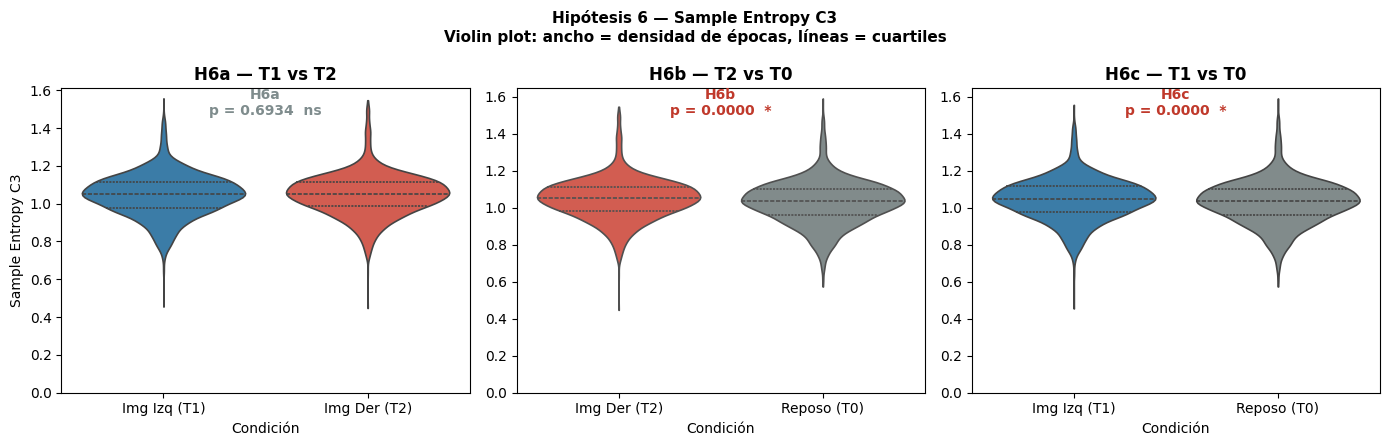

In [35]:
# ── Extraer grupos: Sample Entropy C3 ──────────────────────────
se_T0 = df_features.loc[df_features['tarea'] == 0, 'sampen_C3'].dropna().values
se_T1 = df_features.loc[df_features['tarea'] == 1, 'sampen_C3'].dropna().values
se_T2 = df_features.loc[df_features['tarea'] == 2, 'sampen_C3'].dropna().values

# ── Tres sub-hipótesis ───────────────────────────────────────────
res_6a = prueba_dos_grupos(se_T1, se_T2, 'T1', 'T2', 'SampEn C3', '6a')
res_6b = prueba_dos_grupos(se_T2, se_T0, 'T2', 'T0', 'SampEn C3', '6b')
res_6c = prueba_dos_grupos(se_T1, se_T0, 'T1', 'T0', 'SampEn C3', '6c')

for r in [res_6a, res_6b, res_6c]:
    print(f"H {r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# ── Gráfico: distribuciones de densidad superpuestas ─────────────
# Elegimos violin porque SampEn tiene distribuciones asimétricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares6 = [
    (se_T1, se_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_6a, '6a'),
    (se_T2, se_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_6b, '6b'),
    (se_T1, se_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_6c, '6c'),
]

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares6):
    df_vp = pd.DataFrame({
        'SampEn C3': np.concatenate([ga, gb]),
        'Condición': [NOMBRES_CLASE[{'T0':0,'T1':1,'T2':2}[la]]]*len(ga) +
                     [NOMBRES_CLASE[{'T0':0,'T1':1,'T2':2}[lb]]]*len(gb)
    })
    sns.violinplot(data=df_vp, x='Condición', y='SampEn C3',
                   palette=[ca, cb], ax=ax, inner='quartile',
                   cut=0, linewidth=1.2)
    pv = res['p_value']
    ylim = df_vp['SampEn C3'].quantile(0.98)
    ax.set_ylim(bottom=0)
    ax.annotate(f"H{sid}\np = {pv:.4f}  {'*' if pv<0.05 else 'ns'}",
                xy=(0.5, 0.91), xycoords='axes fraction', ha='center',
                fontsize=10, fontweight='bold',
                color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H6{sid[-1]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('Sample Entropy C3' if sid == '6a' else '')

fig.suptitle('Hipótesis 6 — Sample Entropy C3\n'
             'Violin plot: ancho = densidad de épocas, líneas = cuartiles',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_6_sampen_C3.png', dpi=150, bbox_inches='tight')
plt.show()


| Sub-hipótesis | Grupos | hipótesis |
| --- | --- | --- |
| **3a** | T1 vs T2 | **H₀:** No existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2).<br>**H₁:** Existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y la mano derecha (T2). |
| **3b** | T2 vs T0 | **H₀:** No existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano derecha (T2) y el estado de reposo (T0). |
| **3c** | T1 vs T0 | **H₀:** No existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0).<br>**H₁:** Existen diferencias significativas en el Phase Locking Value de la banda Mu entre los canales C3 y C4 al comparar la imaginación de movimiento de la mano izquierda (T1) y el estado de reposo (T0). |

H 7a | T1 vs T2     | Mann-Whitney U  | p=0.001382 | Rechaza H₀
H 7b | T2 vs T0     | Mann-Whitney U  | p=0.123933 | No rechaza H₀
H 7c | T1 vs T0     | Mann-Whitney U  | p=0.000000 | Rechaza H₀


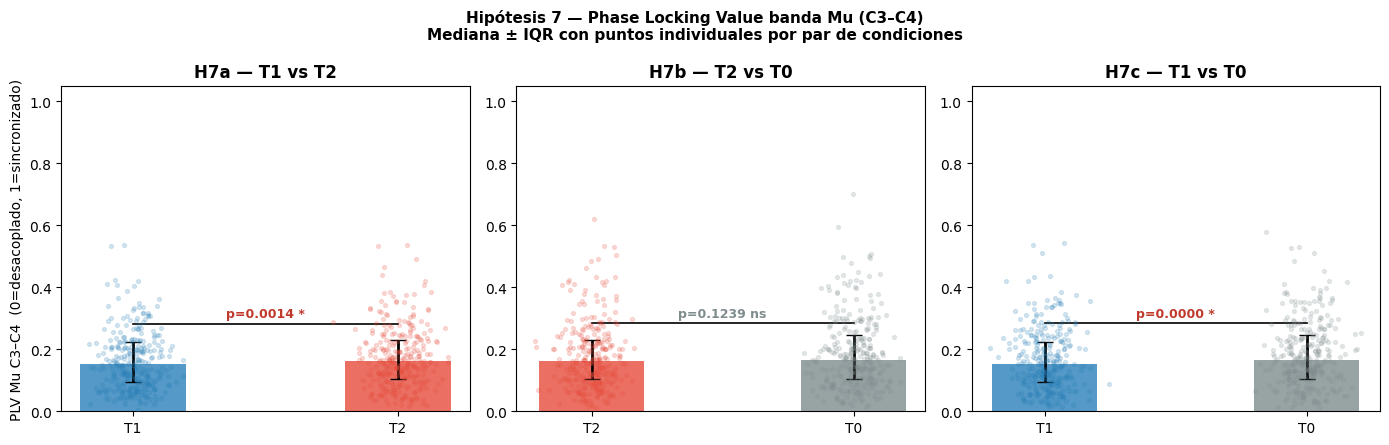

In [36]:
# ── Extraer grupos: PLV Mu C3-C4 ───────────────────────────────
plv_T0 = df_features.loc[df_features['tarea'] == 0, 'plv_c3_c4_mu'].dropna().values
plv_T1 = df_features.loc[df_features['tarea'] == 1, 'plv_c3_c4_mu'].dropna().values
plv_T2 = df_features.loc[df_features['tarea'] == 2, 'plv_c3_c4_mu'].dropna().values

# ── Tres sub-hipótesis ───────────────────────────────────────────
res_7a = prueba_dos_grupos(plv_T1, plv_T2, 'T1', 'T2', 'PLV Mu C3-C4', '7a')
res_7b = prueba_dos_grupos(plv_T2, plv_T0, 'T2', 'T0', 'PLV Mu C3-C4', '7b')
res_7c = prueba_dos_grupos(plv_T1, plv_T0, 'T1', 'T0', 'PLV Mu C3-C4', '7c')

for r in [res_7a, res_7b, res_7c]:
    print(f"H {r['id']} | {r['grupos']:12s} | {r['prueba']:15s} | "
          f"p={r['p_value']:.6f} | {r['decision']}")

# ── Gráfico: barras de mediana con puntos individuales ───────────
# El PLV está acotado entre 0 y 1, las barras son más informativas
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pares7 = [
    (plv_T1, plv_T2, 'T1','T2', COLORES_CLASE[1], COLORES_CLASE[2], res_7a, '7a'),
    (plv_T2, plv_T0, 'T2','T0', COLORES_CLASE[2], COLORES_CLASE[0], res_7b, '7b'),
    (plv_T1, plv_T0, 'T1','T0', COLORES_CLASE[1], COLORES_CLASE[0], res_7c, '7c'),
]

for ax, (ga, gb, la, lb, ca, cb, res, sid) in zip(axes, pares7):
    medias = [np.median(ga), np.median(gb)]
    q25a, q75a = np.percentile(ga, [25, 75])
    q25b, q75b = np.percentile(gb, [25, 75])
    yerr_lo = [medias[0]-q25a, medias[1]-q25b]
    yerr_hi = [q75a-medias[0], q75b-medias[1]]
    bars = ax.bar([la, lb], medias, color=[ca, cb], alpha=0.8, width=0.4)
    ax.errorbar([0, 1], medias,
                yerr=[yerr_lo, yerr_hi],
                fmt='none', color='black', capsize=6, lw=2)
    # Puntos individuales
    for j, (g, col) in enumerate([(ga, ca), (gb, cb)]):
        n_pts = min(300, len(g))
        idx_s = np.random.choice(len(g), n_pts, replace=False)
        ax.scatter(np.random.normal(j, 0.07, n_pts), g[idx_s],
                   color=col, alpha=0.18, s=8, zorder=3)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0, 1]); ax.set_xticklabels([la, lb])
    pv = res['p_value']
    # Barra de significancia
    y_bar = max(medias) + 0.12
    ax.plot([0, 1], [y_bar, y_bar], 'k-', lw=1.2)
    ax.text(0.5, y_bar + 0.02,
            f"p={pv:.4f} {'*' if pv<0.05 else 'ns'}",
            ha='center', fontsize=9, fontweight='bold',
            color='#c0392b' if pv < 0.05 else '#7f8c8d')
    ax.set_title(f'H7{sid[-1]} — {la} vs {lb}', fontweight='bold')
    ax.set_ylabel('PLV Mu C3–C4  (0=desacoplado, 1=sincronizado)' if sid=='7a' else '')

fig.suptitle('Hipótesis 7 — Phase Locking Value banda Mu (C3–C4)\n'
             'Mediana ± IQR con puntos individuales por par de condiciones',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_7_plv_mu.png', dpi=150, bbox_inches='tight')
plt.show()


---
### Resumen global — 13 hipótesis del proyecto

Juntamos los resultados de todas las hipótesis en una sola tabla
y un gráfico de -log₁₀(p) para verlas comparadas.
Las barras que superan la línea roja son estadísticamente significativas.


RESUMEN COMPLETO — 13 HIPÓTESIS
id      variable   grupos         prueba      p_value      decision
 1     PSD Mu C3 T1 vs T2 Mann-Whitney U 3.128291e-02    Rechaza H₀
 2   PSD Beta C4 T1 vs T2 Mann-Whitney U 7.042284e-03    Rechaza H₀
3a     PSD Mu C3 T2 vs T0 Mann-Whitney U 7.417997e-16    Rechaza H₀
3b     PSD Mu C3 T1 vs T0 Mann-Whitney U 2.197663e-08    Rechaza H₀
5a Hjorth Mob C3 T1 vs T2 Mann-Whitney U 4.992390e-01 No rechaza H₀
5b Hjorth Mob C3 T2 vs T0 Mann-Whitney U 9.234700e-02 No rechaza H₀
5c Hjorth Mob C3 T1 vs T0 Mann-Whitney U 3.147230e-01 No rechaza H₀
6a     SampEn C3 T1 vs T2 Mann-Whitney U 6.933780e-01 No rechaza H₀
6b     SampEn C3 T2 vs T0 Mann-Whitney U 0.000000e+00    Rechaza H₀
6c     SampEn C3 T1 vs T0 Mann-Whitney U 0.000000e+00    Rechaza H₀
7a  PLV Mu C3-C4 T1 vs T2 Mann-Whitney U 1.382000e-03    Rechaza H₀
7b  PLV Mu C3-C4 T2 vs T0 Mann-Whitney U 1.239330e-01 No rechaza H₀
7c  PLV Mu C3-C4 T1 vs T0 Mann-Whitney U 0.000000e+00    Rechaza H₀


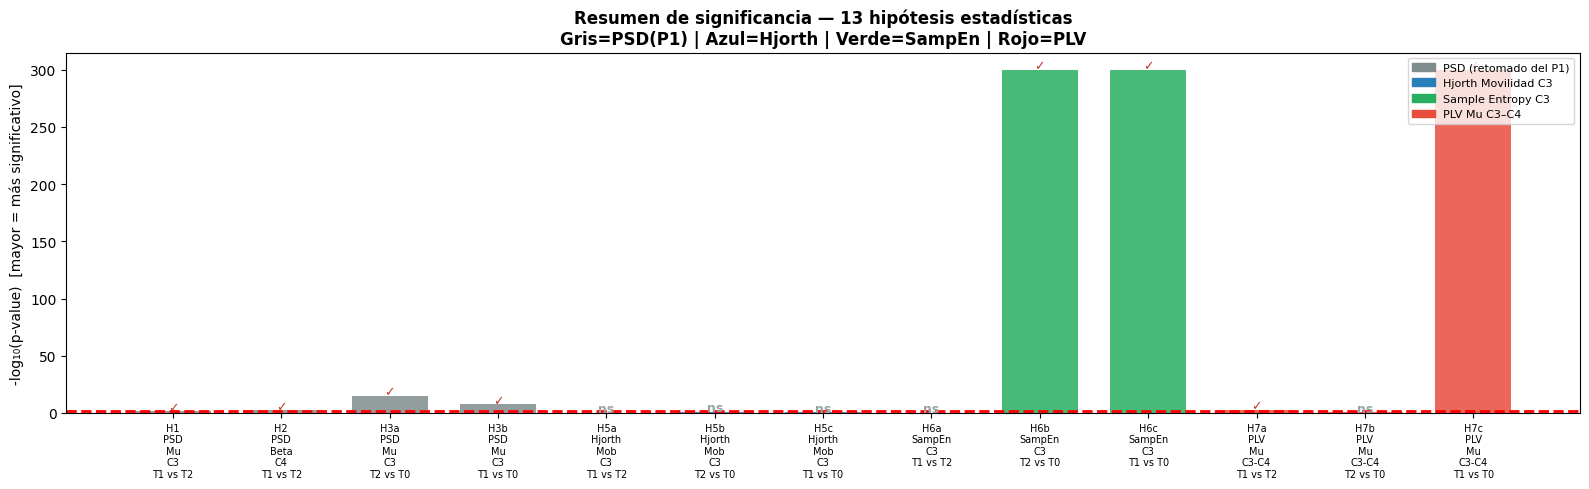


SIGNIFICATIVAS POR BLOQUE:
  PSD (P1 H1-3b): 4/4 significativas
  Hjorth Mob C3 (H5): 0/3 significativas
  SampEn C3 (H6): 2/3 significativas
  PLV Mu C3-C4 (H7): 2/3 significativas


In [37]:
# ── Tabla con todas las hipótesis ───────────────────────────────
todos_res = [
    # Hipótesis del Proyecto 1 (PSD)
    {'id':'1',  'variable':'PSD Mu C3',    'grupos':'T1 vs T2',
     'prueba':prueba_nombre, 'p_value':p_val,   'decision':'Rechaza H₀' if p_val<0.05 else 'No rechaza H₀'},
    {'id':'2',  'variable':'PSD Beta C4',  'grupos':'T1 vs T2',
     'prueba':prueba2,       'p_value':p_val2,  'decision':'Rechaza H₀' if p_val2<0.05 else 'No rechaza H₀'},
    {'id':'3a', 'variable':'PSD Mu C3',    'grupos':'T2 vs T0',
     'prueba':prueba3a,      'p_value':p_val3a, 'decision':'Rechaza H₀' if p_val3a<0.05 else 'No rechaza H₀'},
    {'id':'3b', 'variable':'PSD Mu C3',    'grupos':'T1 vs T0',
     'prueba':prueba3b,      'p_value':p_val3b, 'decision':'Rechaza H₀' if p_val3b<0.05 else 'No rechaza H₀'},
    # Hipótesis nuevas (índices P2)
    res_5a, res_5b, res_5c,
    res_6a, res_6b, res_6c,
    res_7a, res_7b, res_7c,
]

df_resumen = pd.DataFrame(todos_res)[['id','variable','grupos','prueba','p_value','decision']]
print('RESUMEN COMPLETO — 13 HIPÓTESIS')
print('='*85)
print(df_resumen.to_string(index=False))

# ── Gráfico: -log10(p) de las 13 hipótesis ───────────────────────
etiq = [f"H{r['id']}\n{r['variable'].replace(' ','\n')}\n{r['grupos']}"
        for r in todos_res]
pvals_all = [r['p_value'] for r in todos_res]
log_p_all = [-np.log10(p + 1e-300) for p in pvals_all]

# Colores por bloque de hipótesis
colores_bloques = (['#7F8C8D']*4 +   # H1-3b (PSD, Proyecto 1)
                   ['#2980B9']*3 +   # H5 (Hjorth)
                   ['#27AE60']*3 +   # H6 (SampEn)
                   ['#E74C3C']*3)    # H7 (PLV)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(len(pvals_all)), log_p_all,
              color=colores_bloques, alpha=0.85, width=0.7)
ax.axhline(-np.log10(0.05), color='red', ls='--', lw=2,
            label='Umbral p = 0.05')

for i, (bar, pv) in enumerate(zip(bars, pvals_all)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            '✓' if pv < 0.05 else 'ns',
            ha='center', fontsize=9, fontweight='bold',
            color='#c0392b' if pv < 0.05 else '#95a5a6')

ax.set_xticks(range(len(pvals_all)))
ax.set_xticklabels(etiq, fontsize=7)
ax.set_ylabel('-log₁₀(p-value)  [mayor = más significativo]')
ax.set_title('Resumen de significancia — 13 hipótesis estadísticas\n'
             'Gris=PSD(P1) | Azul=Hjorth | Verde=SampEn | Rojo=PLV',
             fontweight='bold')
ax.legend()

# Leyenda de bloques
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#7F8C8D', label='PSD (retomado del P1)'),
    Patch(color='#2980B9', label='Hjorth Movilidad C3'),
    Patch(color='#27AE60', label='Sample Entropy C3'),
    Patch(color='#E74C3C', label='PLV Mu C3–C4'),
]
ax.legend(handles=leyenda, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('figuras_P2/hipotesis_resumen_13.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cuántas resultaron significativas por bloque ──────────────────
print('\nSIGNIFICATIVAS POR BLOQUE:')
bloques = {
    'PSD (P1 H1-3b)'       : todos_res[:4],
    'Hjorth Mob C3 (H5)'   : todos_res[4:7],
    'SampEn C3 (H6)'       : todos_res[7:10],
    'PLV Mu C3-C4 (H7)'    : todos_res[10:13],
}
for bloque, rlist in bloques.items():
    sig = sum(1 for r in rlist if r['p_value'] < 0.05)
    print(f'  {bloque}: {sig}/{len(rlist)} significativas')



#### **9.B. Kruskal-Wallis: selección de características significativas**

Aplicamos el test a cada una de las 19 características para los 3 grupos simultáneos.
Guardamos en `feats_significativas` solo las que tengan p < 0.05.
Estas son las únicas que usaremos en los modelos de clasificación.


In [23]:
from scipy.stats import kruskal

# ── Kruskal-Wallis sobre todas las características ────────────────
# Para cada feature comparamos los 3 grupos: T0, T1, T2
# H0: las medianas de los 3 grupos son iguales
# H1: al menos un grupo tiene mediana diferente

resultados_kw = {}

for col in cols_feat:
    g0 = df_features.loc[df_features['tarea'] == 0, col].dropna().values
    g1 = df_features.loc[df_features['tarea'] == 1, col].dropna().values
    g2 = df_features.loc[df_features['tarea'] == 2, col].dropna().values

    # Necesitamos al menos 2 valores por grupo
    if len(g0) < 2 or len(g1) < 2 or len(g2) < 2:
        continue

    stat_kw, p_kw = kruskal(g0, g1, g2)

    # Tamaño del efecto: eta cuadrado (η²)
    # Fórmula: η² = (H - k + 1) / (N - k)  donde k=3 grupos
    N_total = len(g0) + len(g1) + len(g2)
    k = 3
    eta2 = (stat_kw - k + 1) / (N_total - k)
    eta2 = max(0, eta2)  # no puede ser negativo

    resultados_kw[col] = {
        'H_statistic': round(stat_kw, 4),
        'p_value':     round(p_kw, 6),
        'eta2':        round(eta2, 4),
        'significativa': p_kw < 0.05
    }

# ── Tabla de resultados ───────────────────────────────────────────
df_kruskal = pd.DataFrame(resultados_kw).T.sort_values('p_value')

print('RESULTADOS KRUSKAL-WALLIS — TODAS LAS CARACTERÍSTICAS')
print('='*65)
print(df_kruskal.to_string())

# ── Características que pasan el filtro ──────────────────────────
feats_significativas = df_kruskal[df_kruskal['significativa'] == True].index.tolist()

print(f'\n→ Total características: {len(cols_feat)}')
print(f'→ Significativas (p < 0.05): {len(feats_significativas)}')
print(f'→ Se usarán en los modelos: {feats_significativas}')


RESULTADOS KRUSKAL-WALLIS — TODAS LAS CARACTERÍSTICAS
               H_statistic   p_value    eta2 significativa
psd_mu_C3          74.5416       0.0  0.0074          True
psd_beta_C3        47.6349       0.0  0.0047          True
hjorth_act_C3      55.5815       0.0  0.0055          True
hjorth_act_C4       53.816       0.0  0.0053          True
psd_beta_C4        39.7772       0.0  0.0038          True
sampen_C3          57.2028       0.0  0.0056          True
psd_mu_C4          85.5454       0.0  0.0085          True
sampen_C4          41.4217       0.0   0.004          True
plv_c3_c4_mu       26.7246  0.000002  0.0025          True
psd_mu_Cz          24.7654  0.000004  0.0023          True
psd_beta_Cz        19.3742  0.000062  0.0018          True
hjorth_act_Cz         18.3  0.000106  0.0017          True
hjorth_comp_Cz     14.2077  0.000822  0.0012          True
hjorth_comp_C3      7.1243  0.028378  0.0005          True
hjorth_mob_C4       6.6997   0.03509  0.0005          True
sa

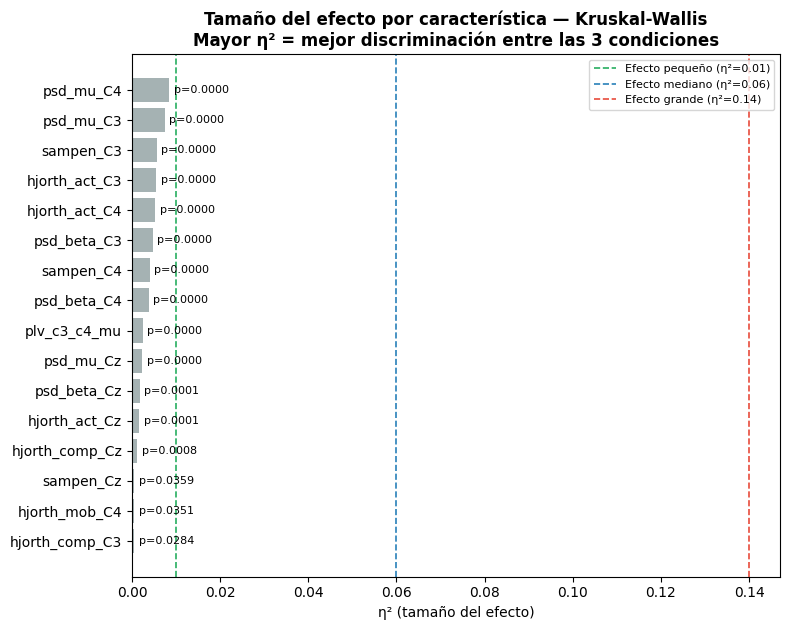

Figura guardada: figuras_P2/hipotesis_00_kruskal_wallis.png


In [24]:
# ── Gráfico: η² de las características significativas ────────────
# El tamaño del efecto nos dice cuánto discrimina cada feature,
# independientemente del p-value (que con N grande casi siempre es < 0.05)

df_sig = df_kruskal[df_kruskal['significativa'] == True].sort_values('eta2', ascending=True)

if len(df_sig) == 0:
    print('Ninguna característica resultó significativa. Revisar los datos.')
else:
    fig, ax = plt.subplots(figsize=(8, max(4, len(df_sig) * 0.4)))

    colores_bar_kw = ['#2980B9' if e >= 0.06 else
                      '#27AE60' if e >= 0.01 else
                      '#95A5A6'
                      for e in df_sig['eta2']]

    barras = ax.barh(df_sig.index, df_sig['eta2'],
                     color=colores_bar_kw, alpha=0.85)

    # Líneas de referencia del tamaño del efecto
    ax.axvline(0.01, ls='--', color='#27AE60', lw=1.2, label='Efecto pequeño (η²=0.01)')
    ax.axvline(0.06, ls='--', color='#2980B9', lw=1.2, label='Efecto mediano (η²=0.06)')
    ax.axvline(0.14, ls='--', color='#E74C3C', lw=1.2, label='Efecto grande (η²=0.14)')

    for bar, (_, row) in zip(barras, df_sig.iterrows()):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f'p={row["p_value"]:.4f}',
                va='center', fontsize=8)

    ax.set_xlabel('η² (tamaño del efecto)')
    ax.set_title('Tamaño del efecto por característica — Kruskal-Wallis\n'
                 'Mayor η² = mejor discriminación entre las 3 condiciones',
                 fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('figuras_P2/hipotesis_00_kruskal_wallis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: figuras_P2/hipotesis_00_kruskal_wallis.png')
